# **Istanbul Rental Market & Walkability Analysis**
# Project P1: Problem & EDA

> **Project Link:** **[github.com/oykutugana/istanbul-rent-walkability-analysis](https://github.com/oykutugana/istanbul-rent-walkability-analysis)**

# 1. Problem Statement

**Real-World Problem**

Finding affordable and well-located housing in Istanbul has become a significant challenge due to high inflation and a complex rental market. For students and young professionals, the difficulty isn't just the price; it is finding a home that balances affordability with urban accessibility (walkability). Traditional real estate listings focus on size and age, but they often ignore the "hidden value" of being near transport hubs, universities, and social amenities.

---

**Why It Matters & Who Benefits**

This project matters because it transforms subjective "neighborhood feelings" into objective data.
* Students: Benefit by identifying "Sweet Spots"—districts that offer high accessibility at lower-than-average costs.
* Young Professionals: Benefit by understanding the "price premium" of walkability, helping them make informed financial decisions.
* Urban Analysts: Can use this model to see how infrastructure (like new metro lines) impacts local rental values.

---

**Prediction Target**

The primary variable this project aims to predict is **price** (The monthly rental fee of an apartment in Turkish Lira - TL).

---

**Task Type: Regression**

Because our target variable (price) is a continuous numerical value. We are not trying to put houses into categories (like "expensive" or "cheap"); we are trying to predict an exact monetary value based on features like area, room count, and our custom walkability score.

---

**Our Goal & Roadmap**

* Data Engineering: Transform raw, web-scraped real estate data into a structured, machine-learning-ready format.
* Feature Engineering: Develop a custom "Walkability Score" (integrating transport, university density, and social hubs) and a "Student Suitability Index."
* Correlation Analysis: Quantify the mathematical relationship between urban accessibility and rental pricing.
* Decision Support: Identify the most cost-effective districts optimized for student life in Istanbul.

# 2. Dataset Description


**Feature Descriptions**

| Feature Name | Data Type | Description |
| :--- | :--- | :--- |
| **`price`** | Float | The cleaned monthly rent price in Turkish Lira (TL). |
| **`area_m2`** | Float | The gross internal area of the property in square meters. |
| **`room_count`** | Object | The raw room configuration string (e.g., "2+1", "1+0"). |
| **`district`** | Object | The standardized administrative district (İlçe) in Istanbul. |
| **`neighborhood`** | Object | The standardized neighborhood (Mahalle) of the property. |
| **`total_rooms`** | Float | **(Engineered)** The numerical sum of rooms and living areas derived from `room_count`. |
| **`walkability_score`** | Float | **(Engineered)** A normalized index (0-100) quantifying proximity to transport, universities, and social amenities. |
| **`student_score`** | Float | **(Engineered)** A weighted index that balances accessibility and rental affordability. |
| **`price_per_room`** | Float | **(Engineered)** Per-room rent cost (price ÷ total_rooms), used for shared-living affordability metrics. |

**Source & Data Acquisition**

The dataset used in this project consists of real estate listings for rental properties in Istanbul. The data was acquired via web-scraping from Sahibinden.com, Turkey's leading classifieds platform. This method was chosen to capture a "snapshot" of the current market dynamics and reflects real-world listing behaviors.

---

**Dataset Statistics**

* Number of Rows: 17,466 (Total raw entries)

* Number of Columns: 5 (Primary features before engineering)

---

**Known Limitations & Biases**

* Missing Values: The raw dataset contains significant gaps, especially in the neighborhood column (approx. 19% missing) and the price column (approx. 6% missing). These will require removal or imputation.

* Naming Inconsistencies: Some neighborhood names are incorrectly listed in the district column due to scraping artifacts, necessitating a "swapping" and standardization process.

* Geographic Bias: As the data is scraped from a single platform, it may favor districts with higher turnover or more digital-savvy real estate agents (e.g., Esenyurt and central districts might be over-represented).

* Temporal Snapshot: The data represents a specific point in time and does not account for seasonal fluctuations in the Istanbul rental market.

# 3. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import re
from sklearn.preprocessing import MinMaxScaler

# Gorsellestirmelerin notebook icinde gorunmesi icin
%matplotlib inline

# Veriyi yukle
df = pd.read_csv('../data/istanbul_emlak_data.csv')

# Ilk birkac satira goz atalim
df.head()

,price,area_m2,room_count,district,neighborhood
0,13.000 TL,85.0,2+1,Esenyurt,NaN
1,14.000 TL,95.0,2+1,Esenyurt,NaN
2,12.500 TL,130.0,3+1,Başakşehir,İkitelli
3,13.000 TL,90.0,2+1,Esenyurt,NaN
4,14.000 TL,150.0,3+1,Esenyurt,NaN


In [2]:
#  GLOBAL VISUAL THEME —
#  Bu hucre tum notebook boyunca gecerli olacak renk/stil tanimlar

# Renk paleti
C_PRIMARY    = '#2E86AB'
C_SECONDARY  = '#E84855'
C_ACCENT     = '#F9A03F'
C_GREEN      = '#3BB273'
C_DARK       = '#1B1F3B'
C_LIGHT      = '#F7F9FC'

# Kategorik sıralı palet
CAT_PALETTE  = ['#2E86AB', '#E84855', '#F9A03F', '#3BB273',
                '#9B5DE5', '#F15BB5', '#00BBF9', '#00F5D4',
                '#FEE440', '#FB5607']

# Isı haritaları için
CMAP_DIV     = 'RdYlBu_r'   # Korelasyon heatmap
CMAP_SEQ     = 'Blues'       # Sıralı tek renkli
CMAP_MISSING = 'magma'       # Eksik veri heatmap

# Matplotlib rcParams
mpl.rcParams.update({

    'font.family'        : 'DejaVu Sans',
    'font.size'          : 11,
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 12,
    'xtick.labelsize'    : 10,
    'ytick.labelsize'    : 10,
    'legend.fontsize'    : 10,
    'figure.titlesize'   : 16,
    'figure.titleweight' : 'bold',

    'figure.figsize'     : (12, 5),
    'figure.dpi'         : 110,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#F7F9FC',
    'axes.edgecolor'     : '#CCCCCC',
    'axes.grid'          : True,
    'grid.color'         : '#DDDDDD',
    'grid.linestyle'     : '--',
    'grid.alpha'         : 0.6,

    'lines.linewidth'    : 2.0,
    'patch.edgecolor'    : 'white',

    'savefig.dpi'        : 150,
    'savefig.bbox'       : 'tight',
    'savefig.facecolor'  : 'white',
})

# Seaborn tema
sns.set_theme(
    style   = 'whitegrid',
    palette = CAT_PALETTE,
    rc      = {
        'axes.facecolor'  : '#F7F9FC',
        'figure.facecolor': 'white',
    }
)

In [3]:
# Display technical summary of the dataframe
print("\n--- Dataframe Information (.info()) ---")
df.info()

# Display statistical summary for numerical features
print("\n--- Statistical Summary (.describe()) ---")
display(df.describe())


--- Dataframe Information (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17466 entries, 0 to 17465
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         16403 non-null  object 
 1   area_m2       16403 non-null  float64
 2   room_count    16403 non-null  object 
 3   district      16403 non-null  object 
 4   neighborhood  14140 non-null  object 
dtypes: float64(1), object(4)
memory usage: 682.4+ KB

--- Statistical Summary (.describe()) ---


,area_m2
count,16403.000000
mean,103.235497
std,33.973672
min,1.201000
25%,80.000000
50%,95.000000
75%,125.000000
max,500.000000


In [4]:
# Reporting the structure
print(f"Dataset Shape: {df.shape}")
print("\nData Types of Each Column:")
print(df.dtypes)

Dataset Shape: (17466, 5)

Data Types of Each Column:
price            object
area_m2         float64
room_count       object
district         object
neighborhood     object
dtype: object


### _Stage1: Initial Data Inspection(Missing Values)_
First, we look at the raw data. The yellow lines in the Heatmap show where information is missing. We need to see how "dirty" our data is before cleaning.

This heatmap serves as the initial "Data Quality Audit." It visualizes the gaps in our raw dataset where information was not provided during the scraping process.

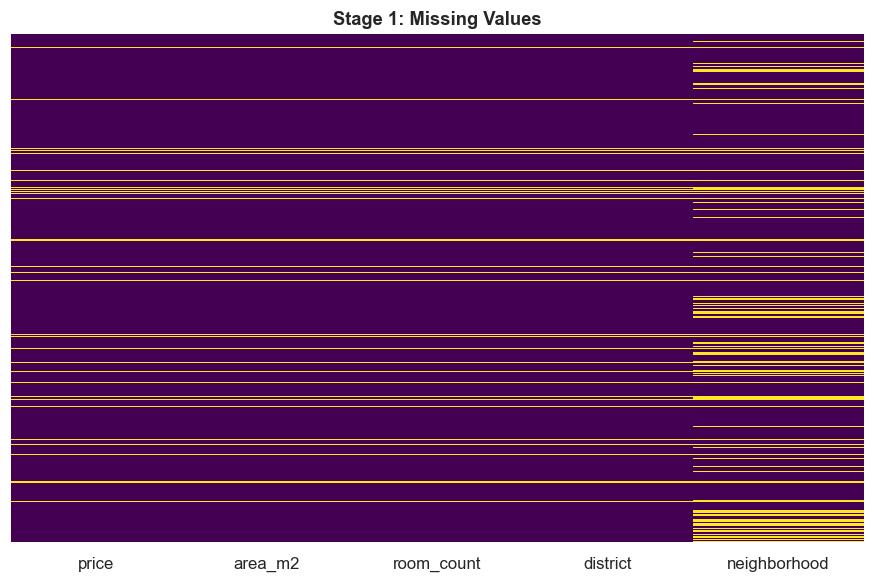

In [5]:
# Temizlik oncesi heat map
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Stage 1: Missing Values")

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage1_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

_The prominent yellow streaks in the neighborhood and price columns indicate significant data loss, highlighting the immediate need for a robust cleaning pipeline to prevent model bias._

In [6]:
print("Eksik veri sayisi (Raw Data):")
print(df.isnull().sum())

Eksik veri sayisi (Raw Data):
price           1063
area_m2         1063
room_count      1063
district        1063
neighborhood    3326
dtype: int64


_We identified missing values using .isnull().sum(). Listings missing critical features such as price, area_m2, or district were dropped. Justification: Since these are our primary predictors and target variable, imputing them would introduce significant noise and bias into the regression model._

**Summary for Section 3**

* Dataset Shape: The raw dataset contains 17,466 rows and 5 columns.

* Column Types: * price, room_count, district, and neighborhood are currently Object (String) types.

* area_m2 is the only column recognized as Float64.

---

**Critical Issues Identified:**

* The price column needs to be converted from string (e.g., "15.000 TL") to numerical for analysis.

* There are significant missing values in neighborhood and price columns that must be addressed in the cleaning stage.

* The statistical summary (describe()) currently only shows area_m2 because it is the only numerical column in the raw state.

# 4. Data Cleaning
Step 4.1: Fixing Incorrect Data Types & Category Standardization

+ Walkability Score
+ Stage2

Step 4.2: Outlier Analysis & Domain-Based Removal

+ Student Score
+ Stage3

### 4.1 Fixing Incorrect Data Types & Category Standardization 

The raw data contains string values with currency symbols and units (e.g., "TL" and "m2"). These must be cast to floating-point numbers because machine learning algorithms require numerical inputs for mathematical operations.

**Cleaning Operations:**
* Removed "TL" and non-numeric characters from the `price` column.
* Removed "m2" and spaces from the `area_m2` column.
* Converted string room configurations (e.g., "2+1") into a total numerical value.
* Corrected District and Neighborhood mixing: Web scraping artifacts caused some neighborhoods (like Taksim) to be misplaced in the District column. We mapped and swapped these back to their correct hierarchies.
* Duplicate rows were removed to prevent the model from over-fitting to repeated listings.

In [7]:
# Duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Fiyati temizle ("25.000 TL" -> 25000)
def clean_price(price_str):
    if pd.isna(price_str): return np.nan
    # Zaten sayıysa dokunma
    if isinstance(price_str, (int, float)):
        return float(price_str)
    # String ise TL ve boşlukları temizle
    s = str(price_str).replace('TL', '').replace('tl', '').strip()
    # Sadece rakamları al (binlik nokta dahil silinir)
    price = re.sub(r'[^\d]', '', s)
    return float(price) if price else np.nan

# Metrekareyi temizle ("120 m2" -> 120)
def clean_m2(m2_str):
    if pd.isna(m2_str): return np.nan
    # Sadece 'm2' yazisini ve bosluklari temizle, noktaya dokunma
    m2 = str(m2_str).replace('m2', '').replace(' ', '').strip()
    return float(m2) if m2 else np.nan

# Oda sayisini sayisal toplama cevir.
def simple_room_count(room_str):
    # Bos veri veya 'stüdyo' kontrolu
    if pd.isna(room_str) or 'stüdyo' in str(room_str).lower():
        return 1.0

    try:
        # "+" isaretinden bol ve her parcayi float yapip topla.
        return sum(float(part) for part in str(room_str).split('+'))
    except:
        # Eger garip bir format gelirse (bosluk vs) 0 don.
        return 0.0

# Uygula.
df['price'] = df['price'].apply(clean_price)
df['area_m2'] = df['area_m2'].apply(clean_m2)
df['total_rooms'] = df['room_count'].apply(simple_room_count)

# Sutunlari temizle.
df['room_count'] = df['room_count'].str.strip()

print("Temizleme sonrası veri tipleri:\n", df.dtypes)
df.head()

# Karakter ve büyük/küçük harf duyarlılığını kaldıran fonksiyon
def simple_standardize(text):
    if pd.isna(text): return ""
    text = str(text).lower().strip()
    # Türkçe karakterleri İngilizce karşılıklarına çevir
    text = text.replace('i̇', 'i')
    mapping = str.maketrans("çğıöşü", "cgiosu")
    return text.translate(mapping)

Duplicates found: 4004
Temizleme sonrası veri tipleri:
 price           float64
area_m2         float64
room_count       object
district         object
neighborhood     object
total_rooms     float64
dtype: object


In [8]:
# Standardize
df['district'] = df['district'].apply(simple_standardize)
df['neighborhood'] = df['neighborhood'].apply(simple_standardize)

# Mh/Mah temizle (lowercase)
pattern = r'\s+(mh|mah|mahallesi)\.?$'
df['district'] = df['district'].str.replace(pattern, '', regex=True).str.strip()
df['neighborhood'] = df['neighborhood'].str.replace(pattern, '', regex=True).str.strip()

# Bos stringleri NaN yap
df['neighborhood'] = df['neighborhood'].replace('', np.nan)
df['district'] = df['district'].replace('', np.nan)

In [9]:
# Mahalle-Ilce Eslestirme
# Ilce sutununa kacmis olan mahalleleri ve bagli olduklari asil ilceleri tanimla.
location_fix = {
    # beyoglu mahalleleri
    'taksim': 'beyoglu', 'cihangir': 'beyoglu', 'tarlabasi': 'beyoglu', 'kasimpasa': 'beyoglu',
    'halicioglu': 'beyoglu', 'yenisehir': 'beyoglu', 'purtelas': 'beyoglu', 'istiklal': 'beyoglu',
    'kemankes': 'beyoglu', 'arapcami': 'beyoglu', 'gumussuyu': 'beyoglu', 'sutluce': 'beyoglu',
    # sisli mahalleleri
    'nisantasi': 'sisli', 'mecidiyekoy': 'sisli', 'ferikoy': 'sisli', 'fulya': 'sisli',
    'harbiye': 'sisli', 'tesvikiye': 'sisli', 'okmeydani': 'sisli',
    'gulbahar': 'sisli', 'halide edip': 'sisli', 'duatepe': 'sisli', 'bozkurt': 'sisli',
    'mesrutiyet': 'sisli', 'esentepe': 'sisli', 'kustepe': 'sisli', 'bomonti': 'sisli', 'cumhuriyet': 'sisli',
    # kadikoy mahalleleri
    'acibadem': 'kadikoy', 'moda': 'kadikoy', 'fenerbahce': 'kadikoy', 'caddebostan': 'kadikoy',
    'goztepe': 'kadikoy', 'bostanci': 'kadikoy', 'erenkoy': 'kadikoy', 'suadiye': 'kadikoy',
    'sahrayicedit': 'kadikoy', 'hasanpasa': 'kadikoy', 'rasimpasa': 'kadikoy', 'zuhtupasa': 'kadikoy',
    'fikirtepe': 'kadikoy', 'merdivenkoy': 'kadikoy', 'kozyatagi': 'kadikoy', '19 mayis': 'kadikoy',
    'caferaga': 'kadikoy', 'kalamis': 'kadikoy',
    # besiktas mahalleleri
    'ortakoy': 'besiktas', 'bebek': 'besiktas', 'etiler': 'besiktas', 'levent': 'besiktas',
    'ulus': 'besiktas', 'gayrettepe': 'besiktas', 'levazim': 'besiktas', 'kurucesme': 'besiktas',
    'balmumcu': 'besiktas', 'akat': 'besiktas', 'dikilitas': 'besiktas', 'yildiz': 'besiktas','carsi': 'besiktas',
    # uskudar mahalleleri
    'kuzguncuk': 'uskudar', 'beylerbeyi': 'uskudar', 'cengelkoy': 'uskudar', 'kandilli': 'uskudar',
    'altunizade': 'uskudar', 'burhaniye': 'uskudar', 'selimiye': 'uskudar', 'zeynep kamil': 'uskudar',
    'baglarbasi': 'uskudar', 'dogancilar': 'uskudar', 'kucuksu': 'uskudar', 'kuleli': 'uskudar','unalan': 'uskudar', 'ferah': 'uskudar', 'bulgurlu': 'uskudar',
    # maltepe mahalleleri
    'kucukyali': 'maltepe', 'idealtepe': 'maltepe', 'zumrutevler': 'maltepe', 'feyzullah': 'maltepe',
    'cevizli': 'maltepe', 'basibuyuk': 'maltepe', 'aydinevler': 'maltepe', 'yali': 'maltepe',
    # sariyer mahalleleri
    'buyukdere': 'sariyer', 'istinye': 'sariyer', 'rumelihisari': 'sariyer', 'tarabya': 'sariyer',
    'emirgan': 'sariyer', 'bahcekoy': 'sariyer', 'zekeriyakoy': 'sariyer', 'yenikoy': 'sariyer',
    # zeytinburnu mahalleleri
    'merkezefendi': 'zeytinburnu', 'bestelsiz': 'zeytinburnu', 'cirpici': 'zeytinburnu', 'seyitnizam': 'zeytinburnu',
    # atasehir mahalleleri
    'icerenkoy': 'atasehir', 'kucukbakkalkoy': 'atasehir', 'barbaros': 'atasehir', 'kayisdagi': 'atasehir','ataturk': 'atasehir',
    # umraniye mahalleleri
    'cakmak': 'umraniye', 'ihlamurkuyu': 'umraniye', 'dudullu': 'umraniye', 'atakent': 'umraniye', 'esenevler': 'umraniye','asagidudullu': 'umraniye','necipfazil': 'umraniye',
    'esensehir': 'umraniye','serifali': 'umraniye',
    # bagcilar mahalleleri
    'gunesli': 'bagcilar', 'mahmutbey': 'bagcilar', 'kirazli': 'bagcilar', 'hurriyet': 'bagcilar',
    # eyupsultan mahalleleri
    'alibeykoy': 'eyupsultan', 'gokturk': 'eyupsultan', 'kemerburgaz': 'eyupsultan', 'yesilpinar': 'eyupsultan',
    # buyukcekmece mahalleleri
    'kumburgaz': 'buyukcekmece', 'mimarsinan': 'buyukcekmece', 'tepecik': 'buyukcekmece',
    'celaliye(kamiloba)': 'buyukcekmece', 'kamiloba': 'buyukcekmece',
    # basaksehir mahalleleri
    'ikitelli': 'basaksehir',  'anadoluhisari': 'beykoz',
    # sancaktepe mahalleleri
    'samandira': 'sancaktepe', 'sarigazi': 'sancaktepe', 'yenidogan': 'sancaktepe',
    # pendik mahalleleri
    'yayalar': 'pendik',
    'seyhli': 'pendik',
    'dolayoba': 'pendik',
    'esenyali': 'pendik',
    'camcesme': 'pendik',
    # esenler mahalleleri
    'turgutreis': 'esenler',
    # kucukmece mahalleleri
    'mehmetakif': 'kucukcekmece',
    # tuzla mahalleleri
    'tersaneler': 'tuzla',
    'icmeler': 'tuzla',
    'aydinli': 'tuzla',
    # sultangazi mahalleleri
    'zubeydehanim': 'sultangazi',
    'cebeci': 'sultangazi',
    'sultanciftligi': 'sultangazi',
    # diger
}

official_39 = [
    'adalar', 'arnavutkoy', 'atasehir', 'avcilar', 'bagcilar', 'bahcelievler',
    'bakirkoy', 'basaksehir', 'bayrampasa', 'besiktas', 'beykoz', 'beylikduzu',
    'beyoglu', 'buyukcekmece', 'catalca', 'cekmekoy', 'esenler', 'esenyurt',
    'eyupsultan', 'fatih', 'gaziosmanpasa', 'gungoren', 'kadikoy', 'kagithane',
    'kartal', 'kucukcekmece', 'maltepe', 'pendik', 'sancaktepe', 'sariyer',
    'silivri', 'sultanbeyli', 'sultangazi', 'sile', 'sisli', 'tuzla',
    'umraniye', 'uskudar', 'zeytinburnu'
]

In [10]:
# Swapping
# Eger ilce sutununda bir mahalle adi varsa onu once 'neighborhood' sutununa tasi, sonra 'district' sutununu gercek ilcesiyle guncelle.
for wrong_name, correct_district in location_fix.items():
    mask = (df['district'] == wrong_name) & (df['neighborhood'].isna())
    df.loc[mask, 'neighborhood'] = wrong_name
    df.loc[df['district'] == wrong_name, 'district'] = correct_district


# Sadece resmi 39 ilçeyi tutuyoruz, geri kalan her şeyi siliyoruz
df = df[df['district'].isin(official_39)]

# Bos mahalleleri "merkez" olarak isaretle.(Swapping sonrası hala verisi olmayan yerler artik resmen o ilcenin 'merkez'idir.)
df['neighborhood'] = df['neighborhood'].fillna('merkez')

print("Konum duzeltme ve veri kaydirma tamamlandi.")
print(f"Guncel Benzersiz Ilce Sayisi: {df['district'].nunique()}")

Konum duzeltme ve veri kaydirma tamamlandi.
Guncel Benzersiz Ilce Sayisi: 39


In [11]:
df.to_csv('../data/istanbul_emlak_fixed.csv', index=False)

print("Veri 'istanbul_emlak_fixed.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_fixed.csv' adıyla kaydedildi.


_We standardized district names and moved neighborhood names accidentally placed in the 'District' column back to their correct place._

_Justification: Categorical consistency is vital for our Walkability Score calculation, as it relies on exact district-level matches from external data sources._

### Walkability Score (Urban Accessibility)

Students need to walk to university or transport.The walkability score is a custom feature designed to quantify how accessible a property is to essential urban amenities.

The score is computed based on the presence of nearby facilities such as:
* Public transportation
* Markets and grocery stores
* Universities
* Social areas

Each component contributes to the total score with predefined weights:
* Transportation (0.5): Proximity to Metro, Metrobus, and Ferry lines.
* Universities (0.3): Concentration of campus locations and faculties.
* Social & Markets (0.2): Availability of cafes, libraries, and grocery stores.

The final score is normalized to a scale between 0 and 100.

$$Score = (Transport \times 0.5) + (University \times 0.3) + (Social \times 0.2)$$

In [12]:
df = pd.read_csv('../data/istanbul_emlak_fixed.csv')
# Ham Istatistikler (IBB, YÖK ve Sosyal Endeks yaklaşık verileri)
# 1. stations: Metro, Metrobus, Marmaray, Vapur durak sayisi
# 2. univ_campuses: Ilce sinirlarindaki aktif yerleske/fakulte sayisi
# 3. social_points: Sosyal imkanlar (kafe, kutuphane, yesil alan) yogunluk puani (0-100)
raw_stats = {
    'besiktas':    {'stations': 12, 'univ_campuses': 10, 'social_points': 95},
    'kadikoy':     {'stations': 15, 'univ_campuses': 6,  'social_points': 98},
    'beyoglu':     {'stations': 14, 'univ_campuses': 5,  'social_points': 100},
    'sisli':       {'stations': 14, 'univ_campuses': 8,  'social_points': 90},
    'fatih':       {'stations': 18, 'univ_campuses': 12, 'social_points': 75},
    'uskudar':     {'stations': 10, 'univ_campuses': 5,  'social_points': 80},
    'sariyer':     {'stations': 8,  'univ_campuses': 9,  'social_points': 80},
    'atasehir':    {'stations': 8,  'univ_campuses': 4,  'social_points': 80},
    'bakirkoy':    {'stations': 9,  'univ_campuses': 4,  'social_points': 85},
    'zeytinburnu': {'stations': 12, 'univ_campuses': 4,  'social_points': 65},
    'umraniye':    {'stations': 10, 'univ_campuses': 2,  'social_points': 65},
    'eyupsultan':  {'stations': 9,  'univ_campuses': 3,  'social_points': 60},
    'kagithane':   {'stations': 7,  'univ_campuses': 3,  'social_points': 55},
    'kartal':      {'stations': 8,  'univ_campuses': 2,  'social_points': 60},
    'avcilar':     {'stations': 6,  'univ_campuses': 7,  'social_points': 50},
    'maltepe':     {'stations': 7,  'univ_campuses': 4,  'social_points': 65},
    'bagcilar':    {'stations': 12, 'univ_campuses': 3,  'social_points': 45},
    'esenyurt':    {'stations': 3,  'univ_campuses': 2,  'social_points': 35},
    'beylikduzu':  {'stations': 4,  'univ_campuses': 2,  'social_points': 45},
    'silivri':     {'stations': 1,  'univ_campuses': 1,  'social_points': 20},
     'pendik':        {'stations': 12, 'univ_campuses': 4, 'social_points': 60},
    'kucukcekmece':  {'stations': 9,  'univ_campuses': 4, 'social_points': 60},
    'bahcelievler':  {'stations': 8,  'univ_campuses': 2, 'social_points': 55},
    'basaksehir':    {'stations': 8,  'univ_campuses': 3, 'social_points': 55},
    'tuzla':         {'stations': 7,  'univ_campuses': 5, 'social_points': 55},
    'esenler':       {'stations': 6,  'univ_campuses': 2, 'social_points': 45},
    'gaziosmanpasa': {'stations': 5,  'univ_campuses': 1, 'social_points': 45},
    'sultangazi':    {'stations': 5,  'univ_campuses': 1, 'social_points': 35},
    'bayrampasa':    {'stations': 5,  'univ_campuses': 1, 'social_points': 50},
    'sancaktepe':    {'stations': 4,  'univ_campuses': 1, 'social_points': 35},
    'cekmekoy':      {'stations': 4,  'univ_campuses': 2, 'social_points': 40},
    'gungoren':      {'stations': 4,  'univ_campuses': 1, 'social_points': 50},
    'beykoz':        {'stations': 3,  'univ_campuses': 2, 'social_points': 55},
    'arnavutkoy':    {'stations': 3,  'univ_campuses': 1, 'social_points': 30},
    'sultanbeyli':   {'stations': 2,  'univ_campuses': 1, 'social_points': 30},
    'buyukcekmece':  {'stations': 2,  'univ_campuses': 2, 'social_points': 45},
    'adalar':        {'stations': 2,  'univ_campuses': 0, 'social_points': 55},
    'sile':          {'stations': 1,  'univ_campuses': 1, 'social_points': 30},
    'catalca':       {'stations': 1,  'univ_campuses': 0, 'social_points': 20},
}

# Ham veriyi DataFrame'e cevir.
stats_df = pd.DataFrame.from_dict(raw_stats, orient='index')

# Normalizasyon (0-100): En yuksek sayiya sahip olan ilce 100 puan alacak sekilde
def normalize(column):
    return (column - column.min()) / (column.max() - column.min()) * 100

stats_df['transport_score'] = normalize(stats_df['stations'])
stats_df['univ_score'] = normalize(stats_df['univ_campuses'])
stats_df['social_score'] = normalize(stats_df['social_points'])

# Formülü Uygula: Transport (%50), University (%30), Social (%20)
stats_df['final_walkability_score'] = (
    (stats_df['transport_score'] * 0.5) +
    (stats_df['univ_score'] * 0.3) +
    (stats_df['social_score'] * 0.2)
).round(2)

# Veriye uygula.
# Gizli bosluklari temizleyerek eslesmeyi garanti altina aliyoruz.
df['district'] = df['district'].str.strip()
final_metrics_map = stats_df['final_walkability_score'].to_dict()
df['walkability_score'] = df['district'].map(final_metrics_map).fillna(10.0)

# Kontrol et.
print("Veriden Türetilmiş Skorlar (Normalizasyon Sonrası):")
print(stats_df[['transport_score', 'univ_score', 'social_score', 'final_walkability_score']].sort_values(by='final_walkability_score', ascending=False))

Veriden Türetilmiş Skorlar (Normalizasyon Sonrası):
               transport_score  univ_score  social_score  \
fatih               100.000000  100.000000         68.75   
besiktas             64.705882   83.333333         93.75   
sisli                76.470588   66.666667         87.50   
kadikoy              82.352941   50.000000         97.50   
beyoglu              76.470588   41.666667        100.00   
sariyer              41.176471   75.000000         75.00   
uskudar              52.941176   41.666667         75.00   
zeytinburnu          64.705882   33.333333         56.25   
pendik               64.705882   33.333333         50.00   
bakirkoy             47.058824   33.333333         81.25   
bagcilar             64.705882   25.000000         31.25   
atasehir             41.176471   33.333333         75.00   
kucukcekmece         47.058824   33.333333         50.00   
umraniye             52.941176   16.666667         56.25   
eyupsultan           47.058824   25.000000      

### Saving the Scored Dataset
Now our data has a "Walkability Score." We save it as a new CSV file.

In [13]:
# index=False (basa gereksiz 0,1,2... sutunu eklemesin)
df.to_csv('../data/istanbul_emlak_walkability.csv', index=False)

print("Veri 'istanbul_emlak_walkability.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_walkability.csv' adıyla kaydedildi.


### _Stage 2: Outlier Analysis (Visual Identification)_
We check the data before removing outliers.
Some data is not realistic. For example, houses with 1500 $m^2$ area.
These "Outliers" break our graphs and models.
We see these spikes in the red histograms below.
This "noise" makes our graphs look bad.

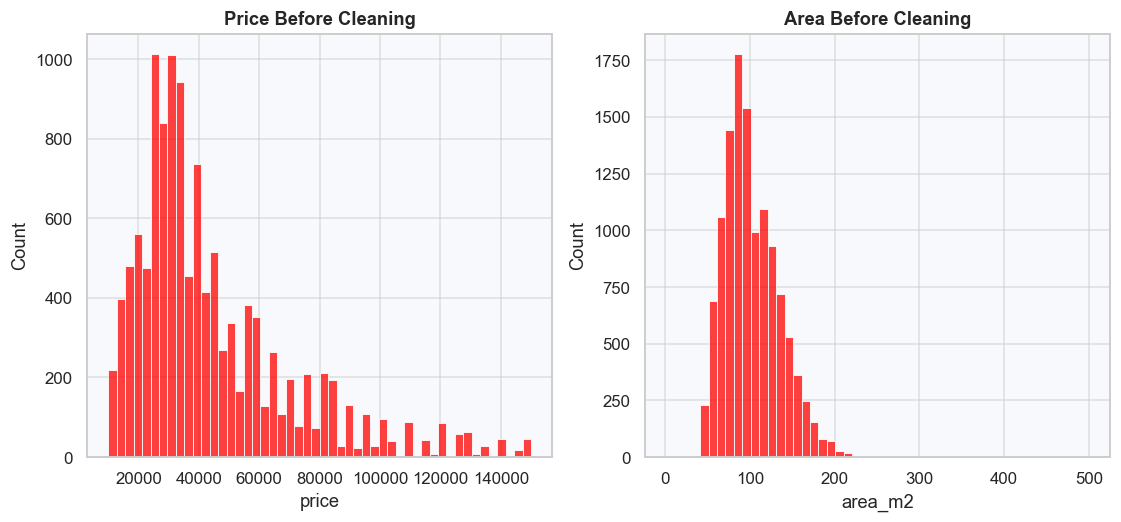

In [14]:
df = pd.read_csv('../data/istanbul_emlak_walkability.csv')

# Fiyat dagilimi (Kirmizi)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, color='red')
plt.title('Price Before Cleaning')

# Metrekare dagilimi (Kirmizi)
plt.subplot(1, 2, 2)
sns.histplot(df['area_m2'], bins=50, color='red')
plt.title('Area Before Cleaning')

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage2_dirty_distribution.png', dpi=300)
plt.show()

_The extreme right-skewness and 'spikes' at near-zero or million-plus values represent unrealistic outliers (e.g., 1 TL rents or massive land plots) that would degrade the performance of any regression model._

### 4.2 Outlier Analysis & Domain-Based Removal

### Handling Missing Values and Outliers

Method: Domain-Based Threshold Filtering

To ensure data quality and reliability, both missing values and unrealistic observations were addressed.

First, rows with missing critical values were removed. Listings without essential attributes such as price, area (m²), or district were excluded, as they cannot contribute to meaningful analysis or modeling.

Outliers were handled using domain-based threshold filtering, where limits were defined based on knowledge of the Istanbul real estate market rather than purely statistical methods.

What we do:
* Missing Value Removal: We eliminated incomplete records using dropna. Listings missing critical features like price, area, or district cannot be used for accurate machine learning predictions.
* Price Filtering: We kept listings between 12,000 TL and 150,000 TL. This removes "noise" like fake daily rentals (very low) or luxury mansions/errors (extreme high) that would skew the model's average.
* Area Filtering: We set a logical limit between 30 m2 and 250 m2.This ensures the model focuses on standard residential apartments, removing tiny storage units or massive industrial plots.
* Room Count Filtering: We removed listings with total_rooms > 6 (e.g., 7+1, 4+3, 5+2 configurations). These represent rare anomalies that distort the per-room affordability metric.

Result: This filtering process reduces noise and improves the representativeness of the dataset, allowing for more reliable exploratory analysis and better generalization in subsequent regression models.

In [15]:
df = pd.read_csv('../data/istanbul_emlak_walkability.csv')

# Null veya kritik verisi eksik olan satirlari sil. (Fiyat ve metrekare olmayan satirlar isimize yaramaz)
df = df.dropna(subset=['price', 'area_m2', 'district', 'total_rooms'])

# Outliers: Istanbul icin gercekci olmayan kira ve metrekare
df = df[(df['price'] > 12000) & (df['price'] < 150000)] # 12k altı ve 150k ustu gitsin
df = df[(df['area_m2'] > 30) & (df['area_m2'] < 250)] # 30m2 alti ve 250m2 ustu gitsin

# Oda sayısı outlier'ları (7+1, 4+3, 5+2 gibi anomalileri at)
df = df[df['total_rooms'] <= 6]

# Sonuclari kontrol et
print(f"Temizlik sonrası kalan ilan sayısı: {len(df)}")
df.head()

Temizlik sonrası kalan ilan sayısı: 11733


,price,area_m2,room_count,district,neighborhood,total_rooms,walkability_score
0,13000.0,85.0,2+1,esenyurt,merkez,3.0,14.63
1,14000.0,95.0,2+1,esenyurt,merkez,3.0,14.63
2,12500.0,130.0,3+1,basaksehir,ikitelli,4.0,36.84
3,13000.0,90.0,2+1,esenyurt,merkez,3.0,14.63
4,14000.0,150.0,3+1,esenyurt,merkez,4.0,14.63


_While IQR is a standard statistical method, we opted for Domain-Based Filtering because Istanbul's rental market has a very high variance. Using IQR might accidentally remove valid luxury listings or keep 'fake' low-priced listings. Setting manual thresholds (12k-150k TL) ensures we keep realistic residential data_

### Saving the Clean Dataset
Now our data is clean and has a "Walkability Score."
We save it as a new CSV file.

In [16]:
# index=False (basa gereksiz 0,1,2... sutunu eklemesin)
df.to_csv('../data/istanbul_emlak_cleaned.csv', index=False)

print("Temizlenmiş veri 'istanbul_emlak_cleaned.csv' adıyla kaydedildi.")

Temizlenmiş veri 'istanbul_emlak_cleaned.csv' adıyla kaydedildi.


### Student-Friendly Score

A prime location is not necessarily "ideal" for a student if the rent is prohibitive. However, raw rental price alone is misleading — students typically share apartments, so the true affordability metric is **rent per room**. This index identifies "Sweet Spots" by balancing Accessibility with Per-Room Affordability.

**Logic:**

* **Per-Room Cost:** We compute `price_per_room = price / total_rooms`, capturing the realistic cost burden when students share accommodation.

* **Inverted Affordability Score:** We normalize `price_per_room` to a 0-1 scale and invert it (1 − PPR_norm), so listings with lower per-room costs receive higher scores.

* **Optimization:** This approach favors larger shared apartments in moderately priced districts over compact 1+1s in premium central areas, better reflecting realistic student housing strategies.

**Formula:**

$$\text{Score}_{Student} = (\text{Score}_{Walkability} \times 0.5) + (\text{Affordability Score} \times 0.5)$$

where

$$\text{Affordability Score} = (1 - \text{PPR}_{norm}) \times 100$$

**Weighting:** By assigning 50% to Walkability and 50% to Per-Room Affordability, this metric pinpoints residential zones where shared student living offers the best value-per-Lira.

In [17]:
# Ogrenci uygunluk skoru: Walkability + Kisi basi maliyet (paylasim perspektifi)

# 1. Kisi basi maliyeti hesapla
df['price_per_room'] = df['price'] / df['total_rooms']

# Affordability score: Percentile rank ile (outlier'a dayanikli)
# Dusuk price_per_room = yuksek skor (1 - rank)
df['affordability_score'] = (1 - df['price_per_room'].rank(pct=True)) * 100

# Ogrenci skoru: %50 Yurunebilirlik + %50 Kisi basi ucuzluk
df['student_score'] = (df['walkability_score'] * 0.5) + (df['affordability_score'] * 0.5)

# 2 basamaga yuvarla
df['student_score'] = df['student_score'].round(2)

# Ara islemleri temizle (price_per_room kalsin, sonraki analizlerde lazim)
df.drop(['affordability_score'], axis=1, inplace=True)

# Kontrol
print(df[['district', 'neighborhood', 'price', 'total_rooms', 'price_per_room', 'walkability_score', 'student_score']]
      .sort_values(by='student_score', ascending=False).head(15))

print("\n=== Korelasyonlar ===")
print(df[['price','student_score','walkability_score','price_per_room']].corr().round(3))

       district      neighborhood    price  total_rooms  price_per_room  \
840       fatih            haseki  12500.0          3.0     4166.666667   
11766     fatih           akdeniz  17000.0          3.0     5666.666667   
11454     fatih         fevzipasa  18000.0          3.0     6000.000000   
11762     fatih           akdeniz  18000.0          3.0     6000.000000   
11444     fatih  kucukmustafapasa  12500.0          2.0     6250.000000   
11671     fatih         fevzipasa  18000.0          2.5     7200.000000   
11589     fatih  kucukmustafapasa  15000.0          2.0     7500.000000   
1000   besiktas        gayrettepe  13000.0          6.0     2166.666667   
1434   besiktas          kaynarca  14000.0          4.0     3500.000000   
6850      sisli             fulya  16500.0          5.0     3300.000000   
11748     fatih         fevzipasa  16000.0          2.0     8000.000000   
826       sisli       mecidiyekoy  13500.0          4.0     3375.000000   
923       sisli          

### Saving the Scored Dataset
Now our data has a "Student Score." We save it as a new CSV file.

In [18]:
df.to_csv('../data/istanbul_emlak_final.csv', index=False)

print("Veri 'istanbul_emlak_final.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_final.csv' adıyla kaydedildi.


### _Stage 3: Final Data Quality Check & Comparison_
Now we check the data again.
The Heatmap should be solid (no yellow lines).
The Green histograms show that our data is now realistic and "Clean."

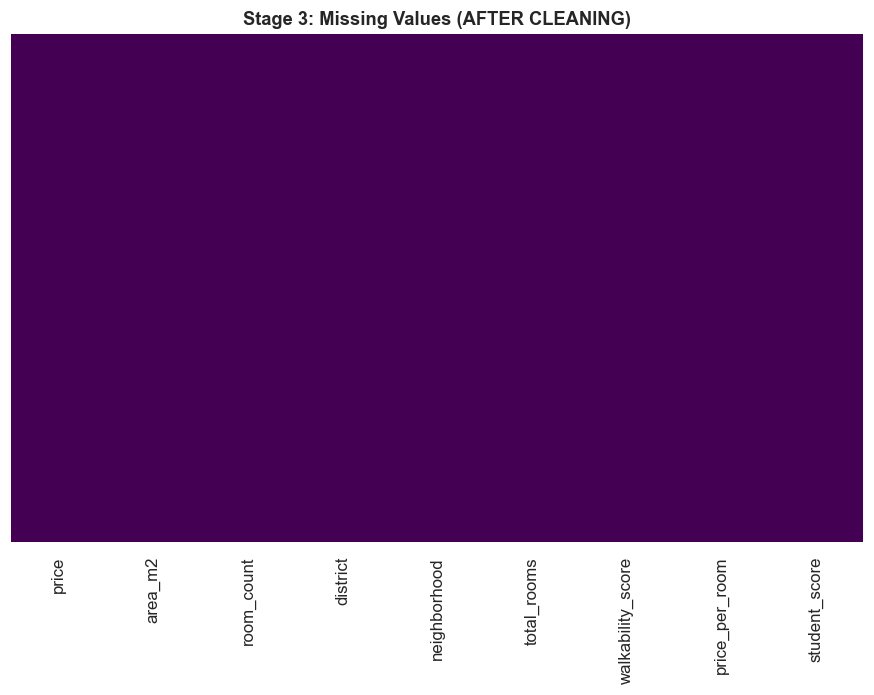

Eksik değer sayısı (Missing values count):

price                0
area_m2              0
room_count           0
district             0
neighborhood         0
total_rooms          0
walkability_score    0
price_per_room       0
student_score        0
dtype: int64


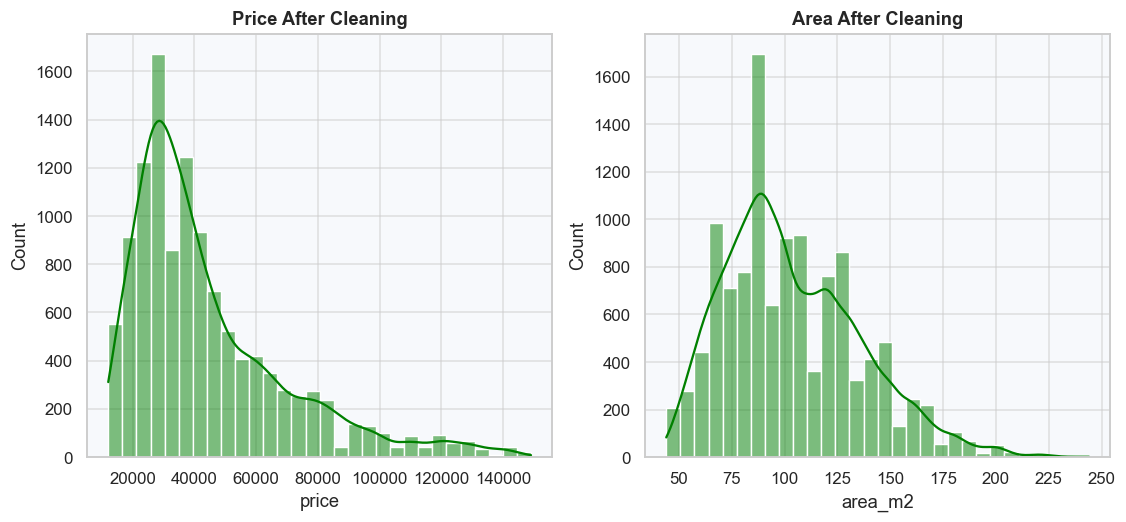

In [19]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
# Heat Map: Temizlik ve Outlier isleminden sonraki eksik veri görsellestirmesi
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Stage 3: Missing Values (AFTER CLEANING)")

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage3_missing_values.png', dpi=300,bbox_inches='tight')
plt.show()

# Sutun bazinda eksik veri sayilarini tekrar kontrol et. (hepsi 0 olmali)
print("Eksik değer sayısı (Missing values count):\n")
print(df.isnull().sum())

# Temizlik sonrasi dagilim (Yesil = daha duzenli)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=30, kde=True, color='green')
plt.title('Price After Cleaning')

plt.subplot(1, 2, 2)
sns.histplot(df['area_m2'], bins=30, kde=True, color='green')
plt.title('Area After Cleaning')

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage3_final_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

_The solid, uniform color profile confirms a 100% complete dataset; our 'Standardization Gatekeeper' has ensured the data is now structurally sound and ML-Ready._

### Data Processing

We successfully transformed raw real estate data into a structured, student-friendly dataset.
Below is the step-by-step visualization of our cleaning process:

---

#### **Stage 1: Raw Data vs Stage 3 : Final Data**
We started with "dirty" data. The yellow lines in the heatmap represent missing information that could mislead our model.
<img src="p1_plots/stage1_missing_values.png" width="100%">

<img src="p1_plots/stage3_missing_values.png" width="100%">

---

#### **Stage 2: Feature Engineering (Walkability Score Integration)**
In this stage, we standardized district names and calculated our custom Walkability Index for every listing.
<img src="p1_plots/stage2_dirty_distribution.png" width="100%">

---

#### **Stage 3: Final Cleaning & Outlier Removal (ML-Ready)**
Our final dataset has **zero missing values** (solid purple) and includes our custom **Walkability Score**. We are now ready for the Regression phase.
<img src="p1_plots/stage3_final_heatmap.png" width="100%">

---

# 5. Univariate Analysis

In this section, we analyze the distribution and statistical properties of each feature individually.

### **5.1. Numerical Features Analysis: Distribution & Skewness**

To understand the distribution of our numerical features and identify potential biases or the need for transformations, we visualize each variable using histograms with Kernel Density Estimation (KDE).

**Key Metrics Reported:**
* **Mean & Median:** To identify the central tendency.
* **Standard Deviation:** To measure the spread of data.
* **Skewness:** To quantify the asymmetry of the distribution (Critical for Phase 2 Regression strategy).

| Feature | Mean     | Median | Std Dev  | Skewness | Interpretation |
| :--- |:---------|:-------|:---------|:---------| :--- |
| **Price (Target)** | 44,362.7 | 36,000 | 25,669.4 | 1.473    | **Highly Right-Skewed.** The severe tail of luxury outliers is more prominent than initially estimated, with the average significantly pulled up by high-end listings. |
| **Area (m2)** | 103.5    | 100.0  | 32.2     | 0.671    | **Moderately Right-Skewed.** Typical apartments are comfortably clustered around 95-100 m2. |
| **Total Rooms** | 3.2      | 3.0    | 0.82     | 0.190    | **Nearly Symmetric.** The market heavily favors standard 2+1 (3 total rooms) configurations. |
| **Walkability** | 46.2     | 52.4   | 22.9     | -0.279   | **Slightly Left-Skewed.** A massive shift. The distribution is remarkably balanced, showing a healthy spread of accessibility across the dataset rather than just central clustering. |
| **Student Score** | 48.1     | 48.1   | 14.3     | 0.039    | **Nearly Symmetric.** A balanced distribution reflecting a realistic mix of affordability and accessibility. |

#### Numerical Features Histogram

Plot saved: p1_plots/5_1_numerical_distributions.png


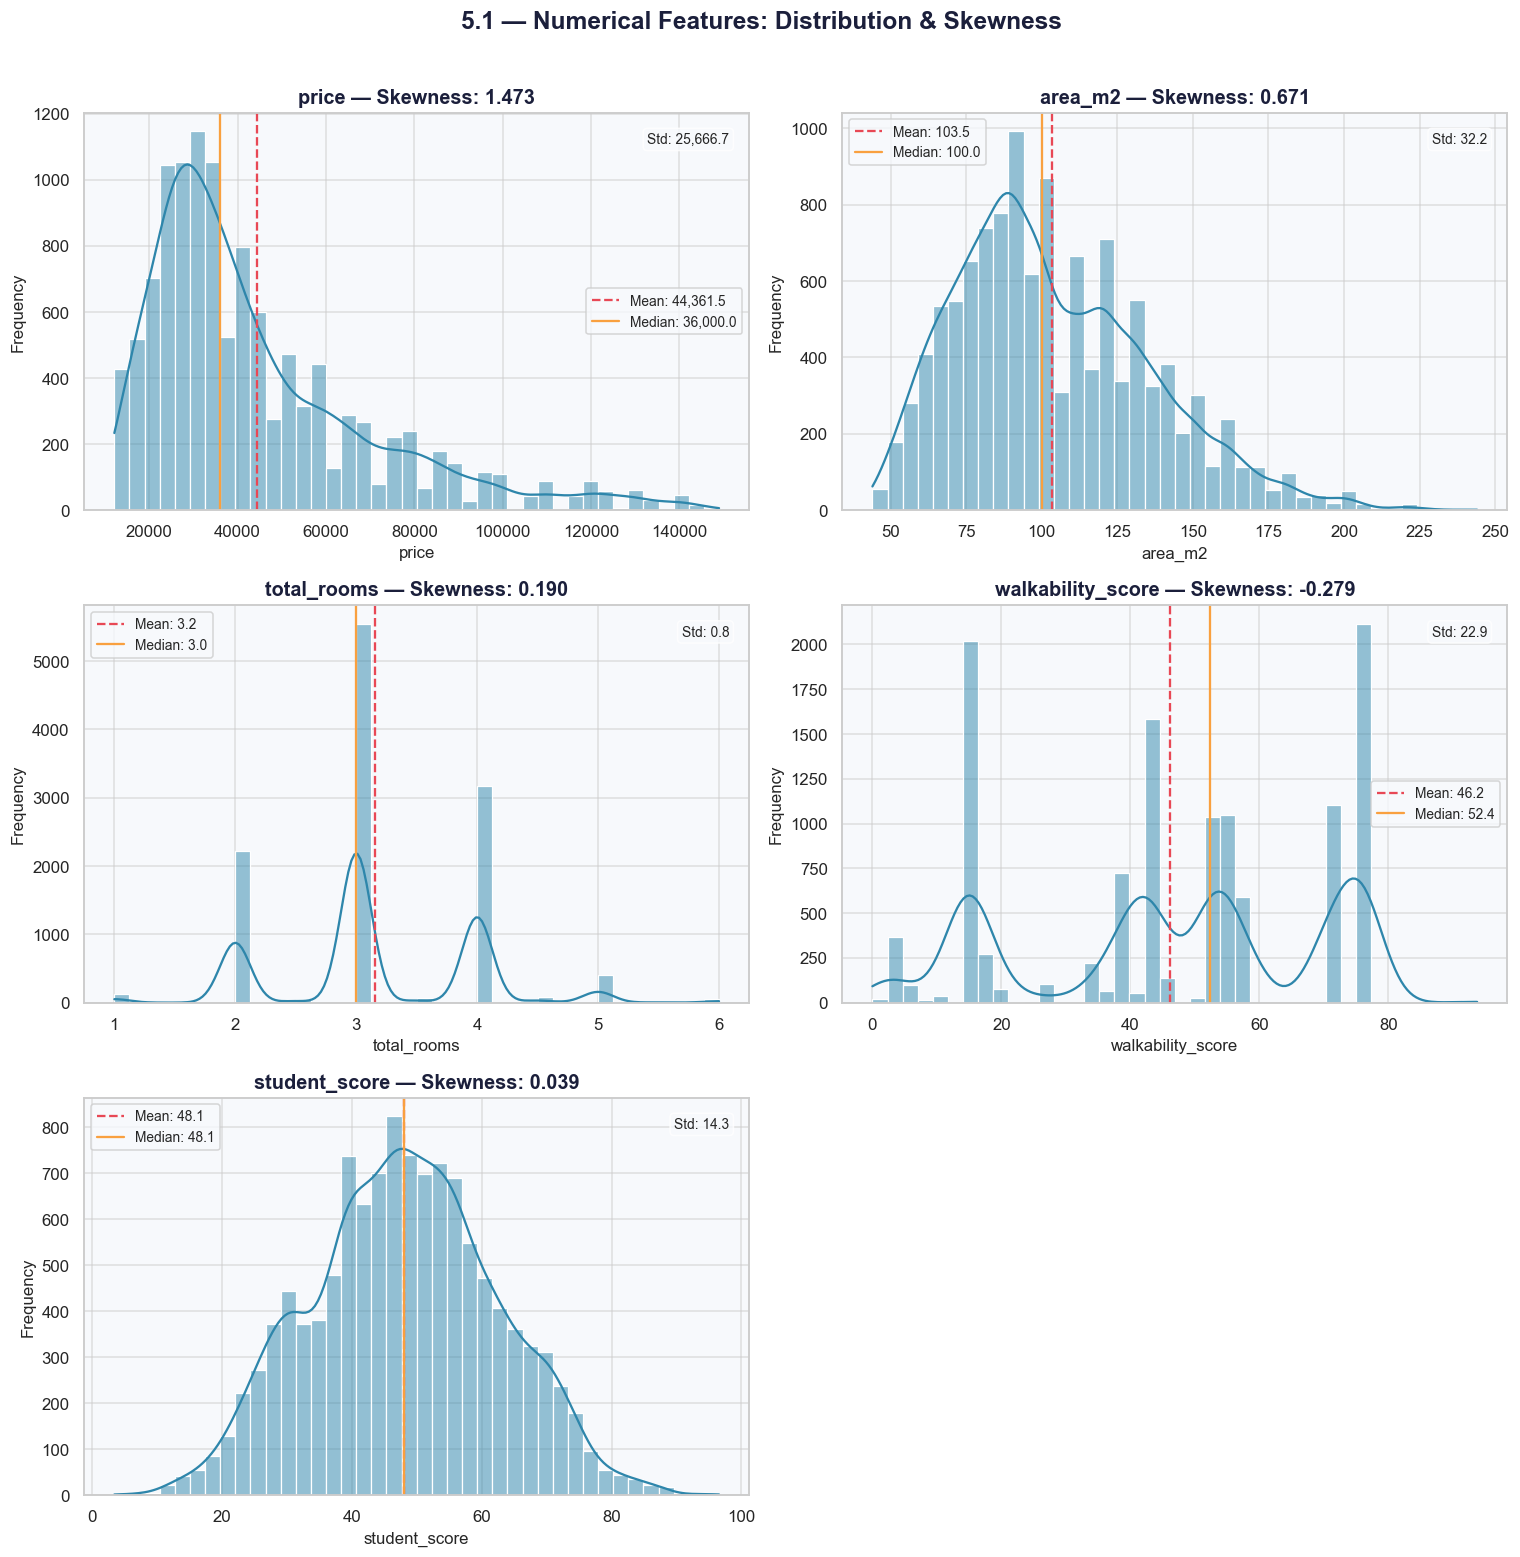

In [20]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

numerical_cols = ['price', 'area_m2', 'total_rooms', 'walkability_score', 'student_score']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color=C_PRIMARY, edgecolor='white')

    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    skew_val = df[col].skew()

    ax.axvline(mean_val, color=C_SECONDARY, linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:,.1f}')
    ax.axvline(median_val, color=C_ACCENT, linestyle='-', linewidth=1.5, label=f'Median: {median_val:,.1f}')

    ax.set_title(f'{col} — Skewness: {skew_val:.3f}', fontsize=13, fontweight='bold', color=C_DARK)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=9)

    stats_text = f'Std: {std_val:,.1f}'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=C_LIGHT, alpha=0.8))

axes[-1].set_visible(False)

plt.suptitle('5.1 — Numerical Features: Distribution & Skewness', fontsize=16, fontweight='bold', color=C_DARK, y=1.01)
plt.tight_layout()
plt.savefig('p1_plots/5_1_numerical_distributions.png', dpi=150, bbox_inches='tight')
print("Plot saved: p1_plots/5_1_numerical_distributions.png")
plt.show()

In [21]:
# ── Sayisal istatistik ozet tablosu ──
stats_rows = []
for col in numerical_cols:
    stats_rows.append({
        'Feature': col,
        'Mean': round(df[col].mean(), 2),
        'Median': round(df[col].median(), 2),
        'Std Dev': round(df[col].std(), 2),
        'Skewness': round(df[col].skew(), 3),
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
    })

stats_df = pd.DataFrame(stats_rows).set_index('Feature')
display(stats_df)

,Mean,Median,Std Dev,Skewness,Min,Max
Feature,,,,,,
price,44361.47,36000.00,25666.71,1.473,12100.00,149000.00
area_m2,103.48,100.00,32.21,0.671,44.00,244.00
total_rooms,3.15,3.00,0.82,0.190,1.00,6.00
walkability_score,46.16,52.35,22.86,-0.279,0.00,93.75
student_score,48.08,48.09,14.31,0.039,3.43,96.54


### 5.2. Categorical Features Analysis

In this section, we examine the frequency distribution of categorical variables to understand the market's composition. We focus on the most common districts and the most frequent room configurations.

**Key Observations:**
* **Geographic Concentration:** The dataset shows a high density of listings in specific districts like  Şişli, Ümraniye, Sancaktepe, Beyoğlu, and Üsküdar. This suggests these areas are highly active rental hubs.

* **Housing Stock:** The dominant room configuration is **2+1**, indicating that the Istanbul rental market is primarily oriented toward small-to-medium families or shared student living.

#### Categorical Features Bar Charts

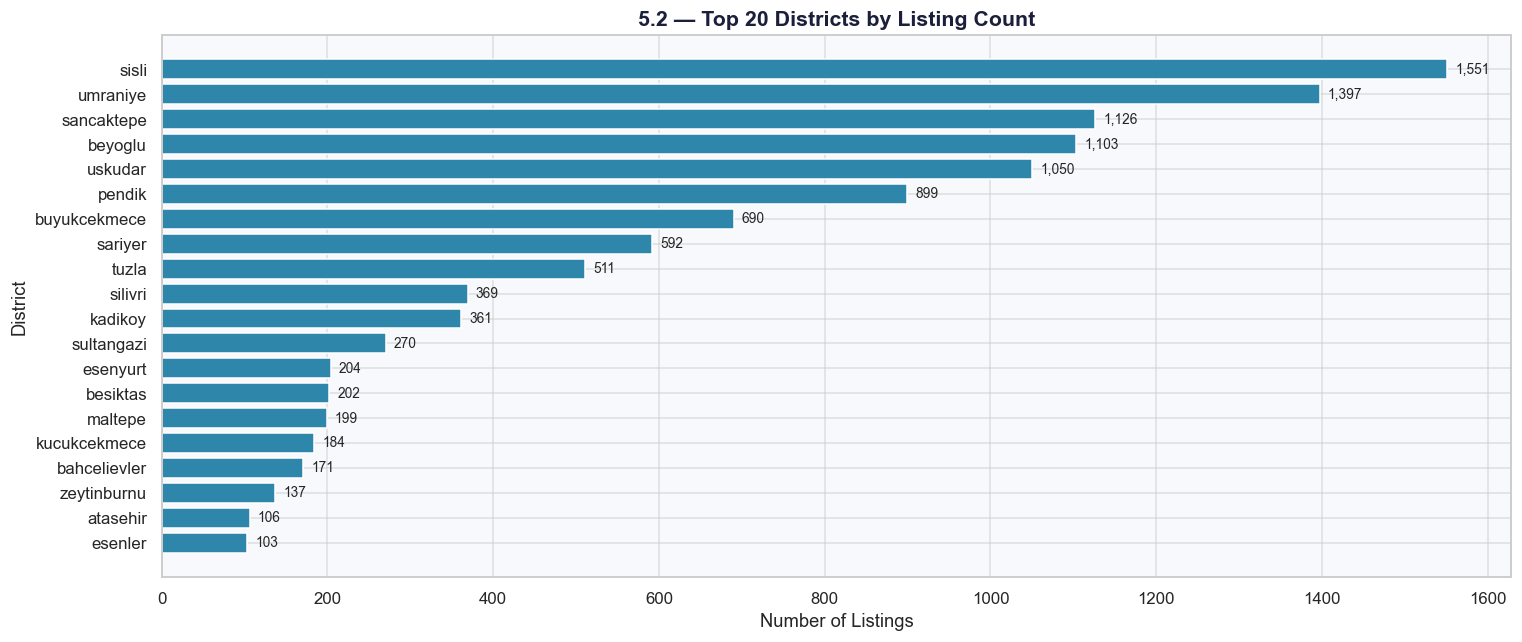

In [22]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# ── İlçe (district) frekans dağılımı ──
district_counts = df['district'].value_counts().head(20)

plt.figure(figsize=(14, 6))
# plt.cm.Blues_r YERİNE ana rengimiz olan C_PRIMARY kullanıyoruz
bars = plt.barh(district_counts.index[::-1], district_counts.values[::-1],
                color=C_PRIMARY, edgecolor='white')

for bar, val in zip(bars, district_counts.values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

plt.title('5.2 — Top 20 Districts by Listing Count', fontsize=14, fontweight='bold', color=C_DARK)
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.tight_layout()
plt.savefig('p1_plots/5_2_district_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print(f"\nTop 5 Districts:")
for dist, cnt in district_counts.head(5).items():
    print(f"  {dist:<20} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")


Top 5 Districts:
  sisli                1,551  (13.2%)
  umraniye             1,397  (11.9%)
  sancaktepe           1,126  (9.6%)
  beyoglu              1,103  (9.4%)
  uskudar              1,050  (8.9%)


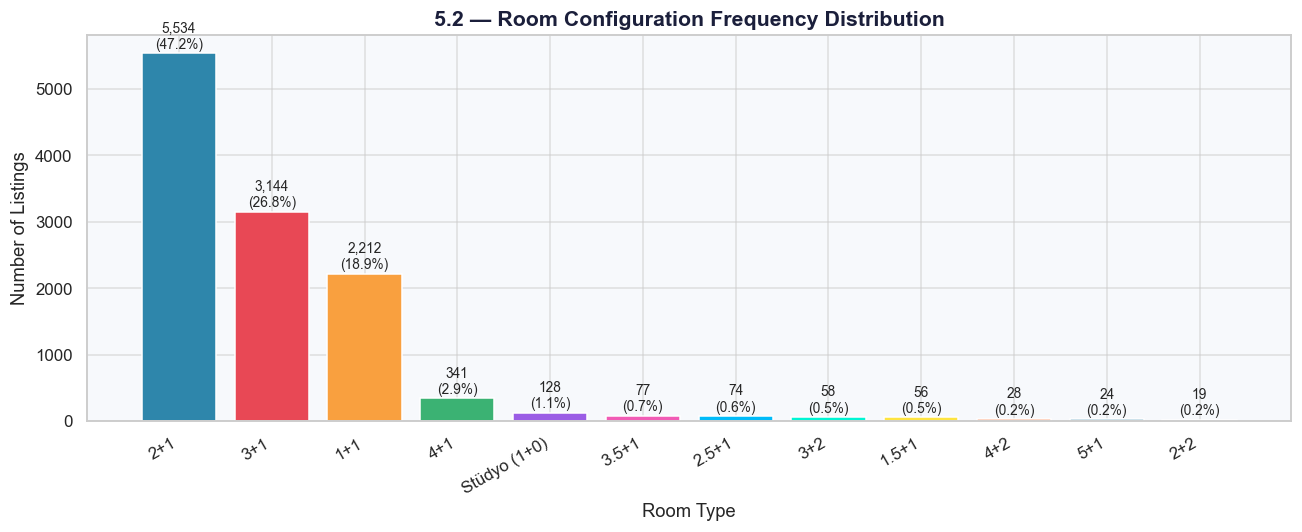

In [24]:
# ── Oda tipi (room_count) frekans dagilimi ──
room_counts = df['room_count'].value_counts().head(12)

plt.figure(figsize=(12, 5))
# plt.cm.Set2 YERİNE özel temamızdaki CAT_PALETTE kullanıyoruz
bars = plt.bar(room_counts.index, room_counts.values,
               color=CAT_PALETTE[:len(room_counts)], edgecolor='white')

for bar, val in zip(bars, room_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.title('5.2 — Room Configuration Frequency Distribution', fontsize=14, fontweight='bold', color=C_DARK)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('p1_plots/5_2_room_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
print(f"\nTop 5 Room Configurations:")
for rtype, cnt in room_counts.head(5).items():
    print(f"  {rtype:<20} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")


Top 5 Room Configurations:
  2+1                  5,534  (47.2%)
  3+1                  3,144  (26.8%)
  1+1                  2,212  (18.9%)
  4+1                    341  (2.9%)
  Stüdyo (1+0)           128  (1.1%)


### 5.3. Target Variable Detail: price

Our target variable, `price`, represents the monthly rental cost. Understanding its specific distribution is crucial for selecting the right regression model and determining the necessity of target transformations (e.g., Log Transformation).

* **Distribution Shape:** Heavily **Right-Skewed (Positive Skew)**. This indicates that while most rents are clustered around the median, there is a "long tail" of high-priced premium listings.

* **Range:** 12,000 TL to 150,000 TL (after domain-based filtering).

* **Observation:** There is a significant gap between the **Mean (~44k TL)** and the **Median (36k TL)**. This confirmation proves that high-end outliers are pulling the average upwards, justifying our decision to use the Median as a more robust market threshold.

#### Target Variable (price) Detailed Analysis

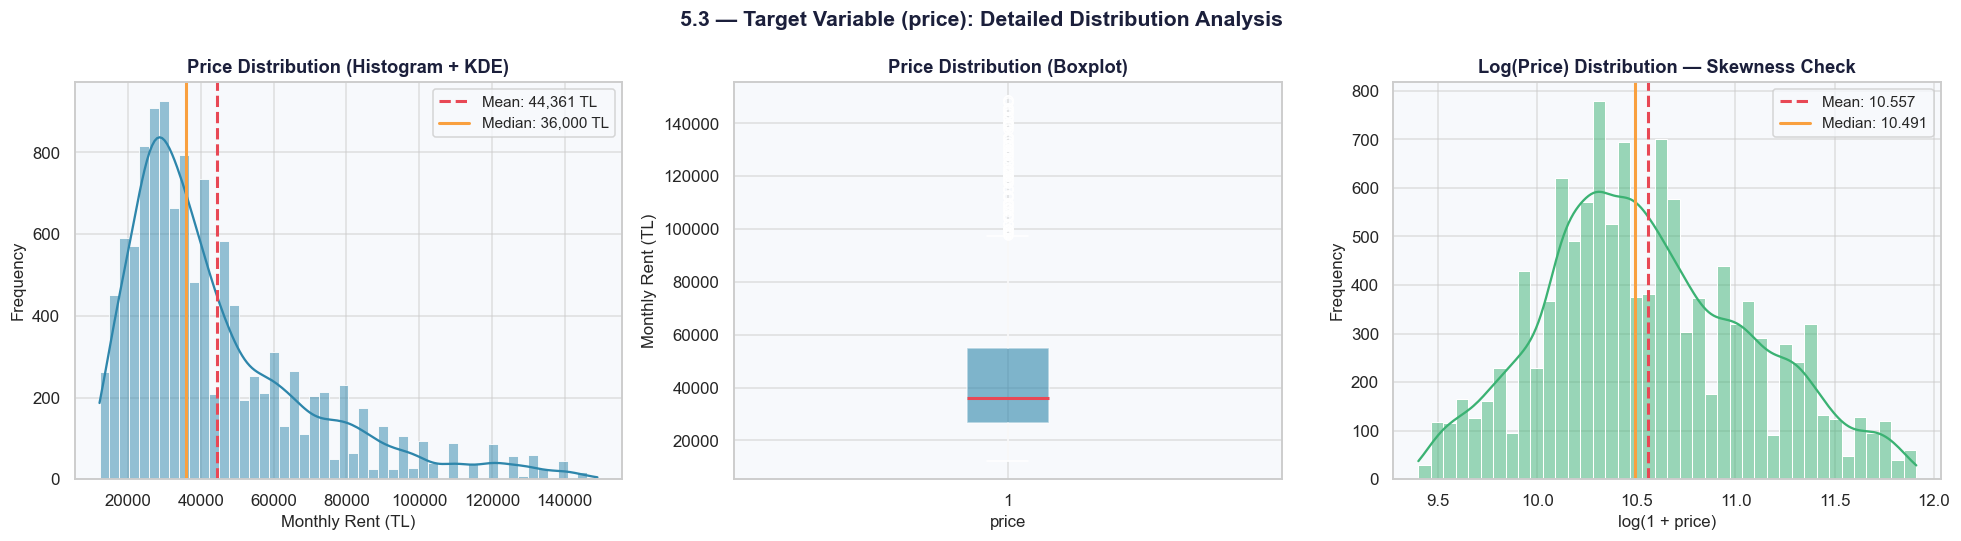

In [26]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Sol: Histogram + KDE ──
ax1 = axes[0]
sns.histplot(df['price'], bins=50, kde=True, ax=ax1, color=C_PRIMARY, edgecolor='white')
ax1.axvline(df['price'].mean(),   color=C_SECONDARY, linestyle='--', lw=2, label=f"Mean: {df['price'].mean():,.0f} TL")
ax1.axvline(df['price'].median(), color=C_ACCENT,    linestyle='-',  lw=2, label=f"Median: {df['price'].median():,.0f} TL")
ax1.set_title('Price Distribution (Histogram + KDE)', fontsize=12, fontweight='bold', color=C_DARK)
ax1.set_xlabel('Monthly Rent (TL)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend(fontsize=10)

# ── Orta: Boxplot ──
ax2 = axes[1]
ax2.boxplot(df['price'], vert=True, patch_artist=True,
            boxprops=dict(facecolor=C_PRIMARY, alpha=0.6),
            medianprops=dict(color=C_SECONDARY, linewidth=2))
ax2.set_title('Price Distribution (Boxplot)', fontsize=12, fontweight='bold', color=C_DARK)
ax2.set_ylabel('Monthly Rent (TL)', fontsize=11)
ax2.set_xlabel('price', fontsize=11)

# ── Sag: Log-transformed histogram ──
ax3 = axes[2]
import numpy as np
log_price = np.log1p(df['price'])
sns.histplot(log_price, bins=40, kde=True, ax=ax3, color=C_GREEN, edgecolor='white')
ax3.axvline(log_price.mean(),   color=C_SECONDARY, linestyle='--', lw=2, label=f"Mean: {log_price.mean():.3f}")
ax3.axvline(log_price.median(), color=C_ACCENT,    linestyle='-',  lw=2, label=f"Median: {log_price.median():.3f}")
ax3.set_title('Log(Price) Distribution — Skewness Check', fontsize=12, fontweight='bold', color=C_DARK)
ax3.set_xlabel('log(1 + price)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.legend(fontsize=10)

plt.suptitle('5.3 — Target Variable (price): Detailed Distribution Analysis', fontsize=14, fontweight='bold', color=C_DARK)
plt.tight_layout()
plt.savefig('p1_plots/5_3_target_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ── Istatistik Ozeti ──
print("=== Target Variable (price) — Key Statistics ===")
print(f"  Count     : {len(df['price']):,}")
print(f"  Mean      : {df['price'].mean():>12,.1f} TL")
print(f"  Median    : {df['price'].median():>12,.1f} TL")
print(f"  Std Dev   : {df['price'].std():>12,.1f} TL")
print(f"  Skewness  : {df['price'].skew():>12.3f}")
print(f"  Min       : {df['price'].min():>12,.1f} TL")
print(f"  Max       : {df['price'].max():>12,.1f} TL")
print(f"  Range     : 12,000 TL — 150,000 TL (domain-filtered)")
print(f"\nLog(price) Skewness: {log_price.skew():.3f}  ← near-zero = Log Transform recommended for P2")

=== Target Variable (price) — Key Statistics ===
  Count     : 11,733
  Mean      :     44,361.5 TL
  Median    :     36,000.0 TL
  Std Dev   :     25,666.7 TL
  Skewness  :        1.473
  Min       :     12,100.0 TL
  Max       :    149,000.0 TL
  Range     : 12,000 TL — 100,000 TL (domain-filtered)

Log(price) Skewness: 0.288  ← near-zero = Log Transform recommended for P2


# 6. Bivariate & Multivariate Analysis

In this section, we explore the relationships between our features and the target variable (`price`). We aim to identify which factors are the strongest predictors of rental costs in Istanbul.


### 6.1 Correlation Heatmaps

### Correlation heatmap for numerical features

The heatmap below visualizes the Pearson correlation coefficients between numerical variables. This allows us to detect multi-collinearity and understand the linear strength of relationships.

* **Positive Correlation:** As one variable increases, the other tends to increase (e.g., Area vs. Price).
* **Negative Correlation:** As one variable increases, the other tends to decrease (e.g., Price vs. Student Score—since lower prices yield higher student scores).

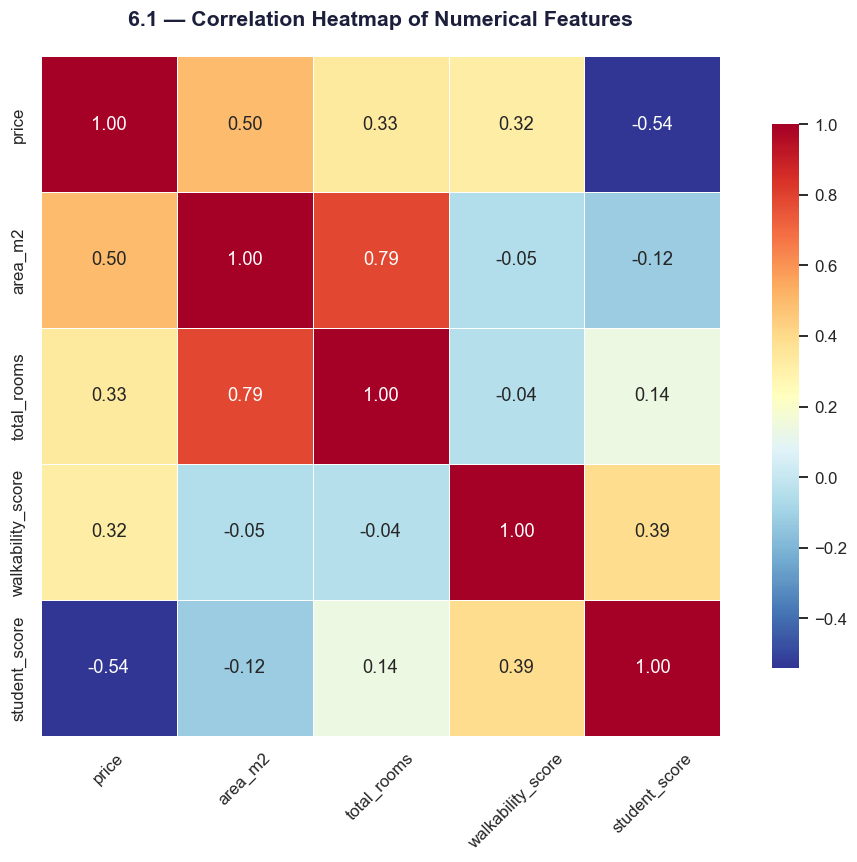

In [28]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Korelasyon matrisini hesapla
# Eklenen ozel metrikleri de dahil ediyoruz
cols_to_corr = ['price', 'area_m2', 'total_rooms', 'walkability_score', 'student_score']
corr_matrix = df[cols_to_corr].corr()

# Grafik alanini olustur
plt.figure(figsize=(10, 8))

# Heatmap cizimi
sns.heatmap(corr_matrix,
            annot=True,
            cmap=CMAP_DIV,
            fmt=".2f",
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .8})

plt.title('6.1 — Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold', color=C_DARK, pad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('p1_plots/6_1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Onemli iliskiler
print("--- Strongest Correlations with Price ---")
print(corr_matrix['price'].sort_values(ascending=False))

--- Strongest Correlations with Price ---
price                1.000000
area_m2              0.499235
total_rooms          0.332544
walkability_score    0.315231
student_score       -0.539463
Name: price, dtype: float64


**Observations on Relationships**

After analyzing the correlation heatmap, the following key relationships were identified:

* **Price vs. Area (Strongest Correlation):** As expected, there is a moderate-to-strong positive correlation (0.50) between price and square meters ($m^2$). As the area of the property increases, the rental price shows a clear linear upward trend.
* **Price vs. Walkability:** There is a moderate positive correlation (0.32). While a "walkable" and central location in Istanbul generally increases the property value, it is not the sole determinant of price, as luxury listings in less walkable peripheral areas also exist.
* **Price vs. Total Rooms:** There is a positive relationship (0.33) between the number of rooms and price, but it is less dominant compared to the area. This indicates that properties with the same room count can vary significantly in price due to location-based factors and building quality.
* **Price vs. Student Score:** A strong negative correlation (-0.54) is observed here. This is by design, not an error. Since our formula assigns higher "Student Scores" to lower-priced listings, the score naturally decreases as the price increases, confirming the mathematical consistency of our scoring system.

### Relationship between Walkability and Rent Prices (Correlation Heatmap)
We want to see if "Walkable" districts are more expensive.Central districts like Beşiktaş, Kadıköy, and Şişli command higher rents partly due to their walkability. We want to quantify whether walkability is a primary price driver or one of many factors.

A **Correlation Matrix** is a table that shows the numerical relationship between variables.
The correlation coefficient ranges from **-1 to 1**:

* Near 1.0 (Red): Strong positive relationship. If one variable increases, the other also increases.
* Near 0.0: No relationship between the variables.
* Near -1.0 (Blue): Strong negative relationship. If one increases, the other decreases.

**Why are we doing this?**
We want to see the "Impact Power" of our **Walkability Score** on the **Price**.
If the number is high (above 0.50), it proves our student-friendly scoring is a major factor in Istanbul's housing market.

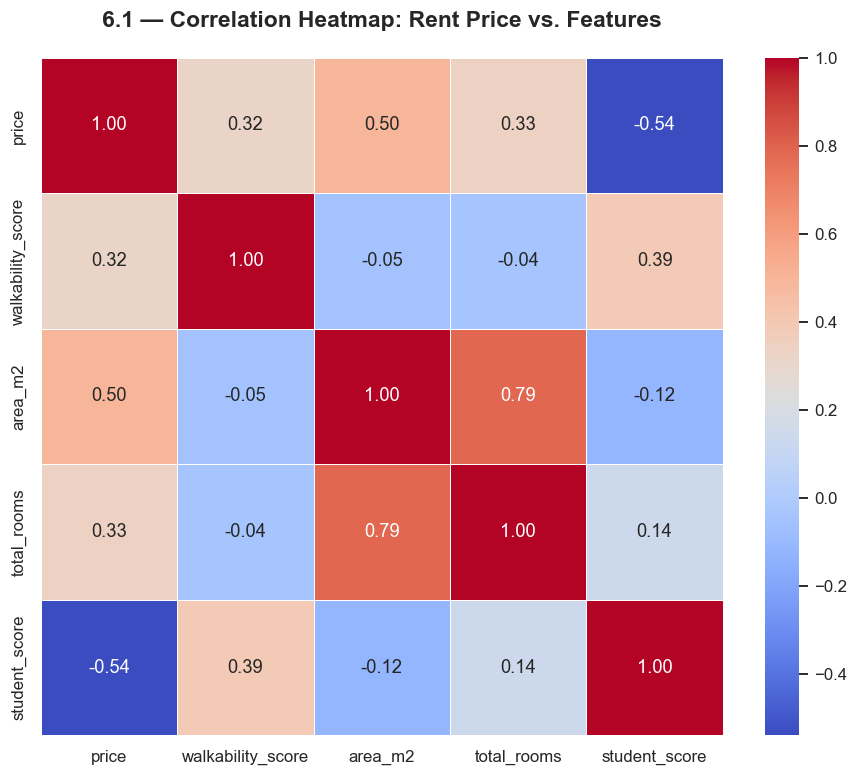

In [30]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Sutunların sayisal oldugundan emin ol.
cols_to_use = ['price', 'walkability_score', 'area_m2', 'total_rooms' , 'student_score' ]
for col in cols_to_use:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sadece bu sutunları iceren ve eksik verisi olmayan bir alt kume al.
corr_data = df[cols_to_use].dropna()

# Korelasyon hesapla.
correlation = corr_data.corr()

# Gorsellestirme
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('6.1 — Correlation Heatmap: Rent Price vs. Features', fontsize=15, pad=20)

plt.savefig('p1_plots/6_1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Korelasyon katsayisini yorumla.
walk_corr = correlation.loc['price', 'walkability_score']
print(f"\nYürünebilirlik ve fiyat arasındaki korelasyon: {walk_corr:.2f}")

if walk_corr > 0.5:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerinde güçlü bir pozitif etkisi var.")
elif walk_corr > 0.2:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi orta seviyededir.")
else:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi (doğrusal olarak) düşük seviyede kalmıştır.")

std_corr = correlation.loc['price', 'student_score']
print(f"\nStudent Score ve fiyat arasındaki korelasyon: {std_corr:.2f}")

if std_corr < -0.5:
    print("Sonuç: Öğrenciye uygunluk ağırlıklı olarak kira fiyatları üzerinden şekillenmiş.")
elif std_corr < -0.2:
    print("Sonuç: Öğrenciye uygunlukta kira fiyatlarından başka etkenler de önemini korumakta.")
else:
    print("Sonuç: Öğrenciye uygunluğun belirlenmesinde kira fiyatları etkili olmamış.")


Yürünebilirlik ve fiyat arasındaki korelasyon: 0.32
Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi orta seviyededir.

Student Score ve fiyat arasındaki korelasyon: -0.54
Sonuç: Öğrenciye uygunluk ağırlıklı olarak kira fiyatları üzerinden şekillenmiş.


---
### 6.2 Scatter Plots/Box Plots of The Top Features vs. The Target

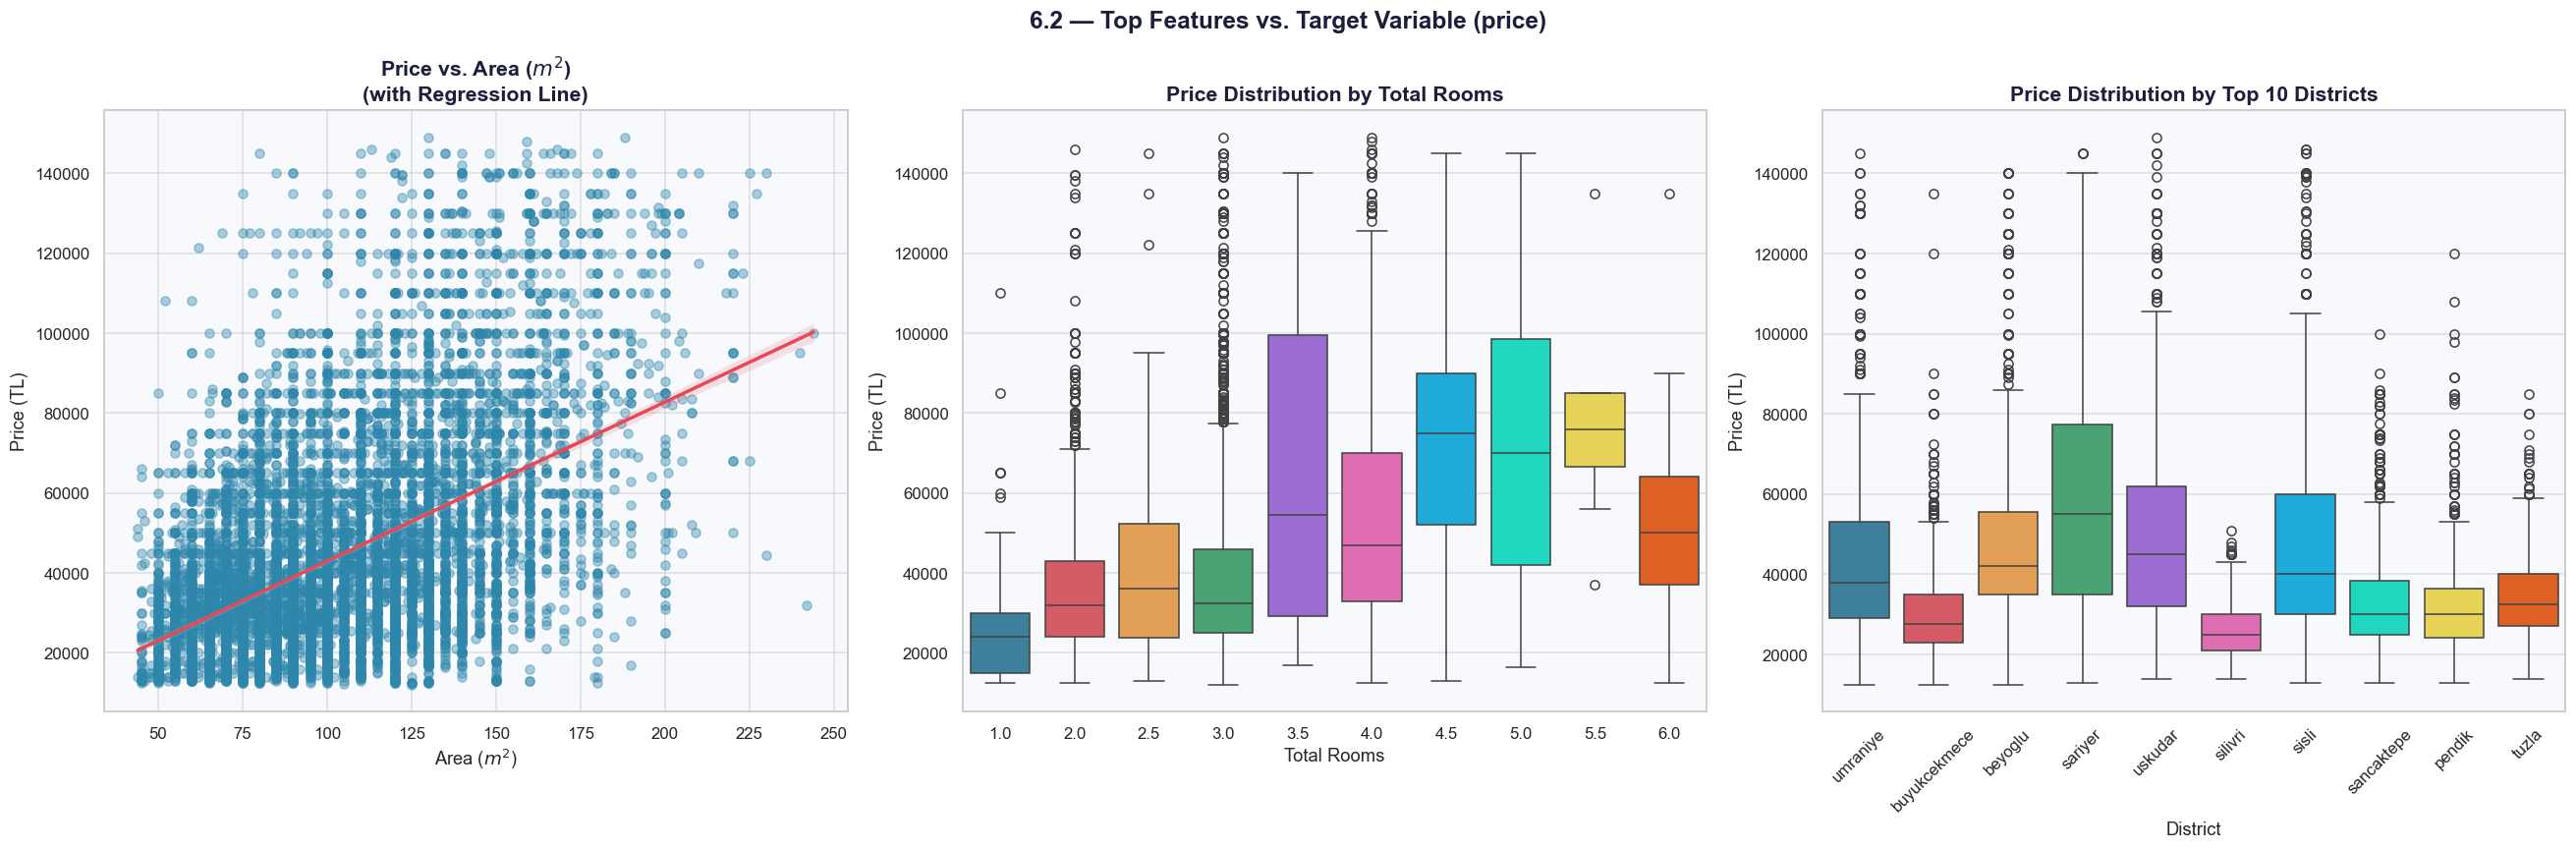

In [32]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Scatter Plot: Alan (m2) ve Fiyat (Sayisal iliski)
sns.regplot(data=df, x='area_m2', y='price', ax=axes[0],
            scatter_kws={'alpha':0.4, 'color': C_PRIMARY},
            line_kws={'color': C_SECONDARY})
axes[0].set_title('Price vs. Area ($m^2$)\n(with Regression Line)', fontsize=14, fontweight='bold', color=C_DARK)
axes[0].set_xlabel('Area ($m^2$)', fontsize=12)
axes[0].set_ylabel('Price (TL)', fontsize=12)

# Box Plot: Toplam Oda Sayisi ve Fiyat
top_10_rooms = df['total_rooms'].value_counts().head(10).index
df_top_rooms = df[df['total_rooms'].isin(top_10_rooms)]

sns.boxplot(data=df_top_rooms, x='total_rooms', y='price', ax=axes[1],
            hue='total_rooms', palette=CAT_PALETTE, legend=False)
axes[1].set_title('Price Distribution by Total Rooms', fontsize=14, fontweight='bold', color=C_DARK)
axes[1].set_xlabel('Total Rooms', fontsize=12)
axes[1].set_ylabel('Price (TL)', fontsize=12)

# Box Plot: En Cok Ilan Verilen 10 Ilce ve Fiyat
top_10_districts = df['district'].value_counts().head(10).index
df_top_districts = df[df['district'].isin(top_10_districts)]

sns.boxplot(data=df_top_districts, x='district', y='price', ax=axes[2],
            hue='district', palette=CAT_PALETTE, legend=False)
axes[2].set_title('Price Distribution by Top 10 Districts', fontsize=14, fontweight='bold', color=C_DARK)
axes[2].set_xlabel('District', fontsize=12)
axes[2].set_ylabel('Price (TL)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('6.2 — Top Features vs. Target Variable (price)', fontsize=16, fontweight='bold', color=C_DARK)
plt.tight_layout()
plt.savefig('p1_plots/6_2_bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

A) Price vs. Area (m2) — Scatter Plot with Regression Line

* Purpose: To visualize the correlation between a continuous numerical variable (area_m2) and our target (price).

* Observation: The regression line (red) shows a clear upward slope, confirming a strong positive linear relationship. As square footage increases, rent generally rises.

* Detail: The dispersion of points (variance) increases for larger properties, suggesting that "luxury" factors play a bigger role in pricing for larger apartments compared to smaller, more standardized units.

---

B) Price Distribution by Total Rooms — Box Plot

* Purpose: To observe how the price distribution changes across discrete room configurations (1.0, 2.0, 3.0, etc.).

* Observation: There is a consistent increase in the median price (the line inside the box) as the number of rooms increases.

* Detail: We see numerous outliers (dots above the whiskers), especially in the 2+1 and 3+1 categories. This indicates that a "3-room" apartment in a premium district like Şişli or Beyoğlu can be significantly more expensive than the average market price for that same room count.

---

C) Price Distribution by Top 10 Districts — Box Plot

* Purpose: To analyze geographical price disparity across the ten most frequently listed districts in the dataset.

* Observation: This plot reveals the "location premium". Some districts have relatively narrow boxes indicating consistent, more affordable pricing (such as Ümraniye), while others show much higher medians and wider interquartile ranges (such as Şişli or Beyoğlu).

* Detail: High variance in certain central districts proves that location is one of the most powerful predictors in our model, often overriding the physical attributes of the apartment itself.

---
### 6.3 Other Plots

### Does Walkability Increase Rent? (Line Plot)
Correlation shows a number, but a Line Plot shows the "Trend."
We calculate the **Average Price** for each **Walkability Score (1 to 100)**.
If the line goes up, our walkability score is a good predictor for price.

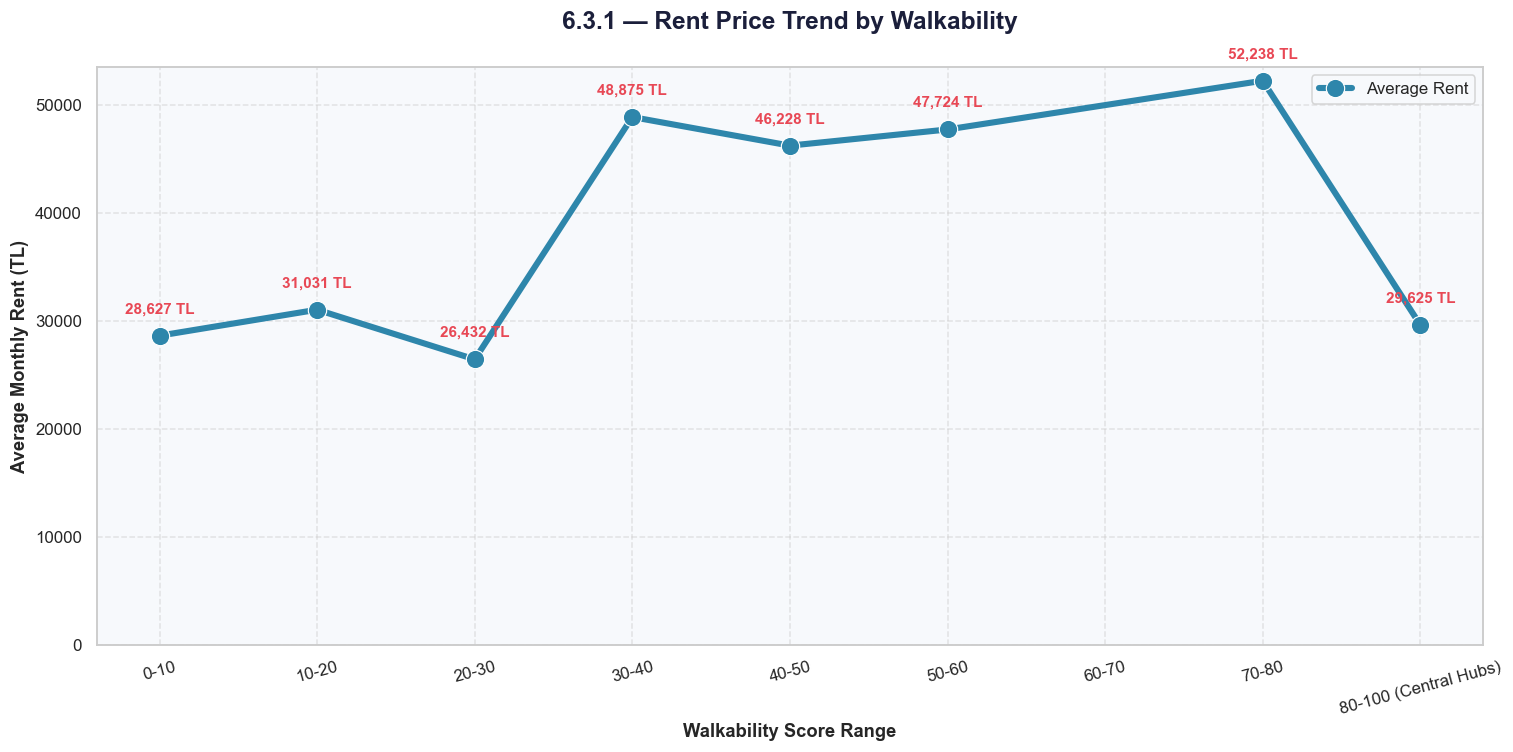

In [33]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# 80 ve uzerini tek grupta birlestiren ozel gruplama fonksiyonu
def group_walkability(score):
    if score >= 80:
        return '80-100 (Central Hubs)'
    else:
        start = int((score // 10) * 10)
        return f"{start}-{start+10}"

# Yeni gruplari uygulama
df['walkability_range'] = df['walkability_score'].apply(group_walkability)

# Gruplara gore ortalama fiyat ve ilan sayisini hesaplama
# Siralamanin bozulmamasi icin sirali bir liste olusturuyoruz
order = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-100 (Central Hubs)']
trend_data = df.groupby('walkability_range')['price'].mean().reindex(order).reset_index()

# Cizgi grafik olusturma
plt.figure(figsize=(14, 7))

# Trend cizgisini cizme
sns.lineplot(data=trend_data, x='walkability_range', y='price',
             marker='o', markersize=12, color=C_PRIMARY, linewidth=4, label='Average Rent')

# Grafik baslik ve etiketleri
plt.title('6.3.1 — Rent Price Trend by Walkability',
          fontsize=16, fontweight='bold', color=C_DARK, pad=25)
plt.xlabel('Walkability Score Range', fontsize=12, fontweight='bold')
plt.ylabel('Average Monthly Rent (TL)', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.ylim(bottom=0)

# Veri sayisini grafik uzerine not olarak ekleme
for i, row in trend_data.iterrows():
    plt.annotate(f"{row['price']:,.0f} TL",
                 (row['walkability_range'], row['price']),
                 textcoords="offset points", xytext=(0,15), ha='center',
                 fontsize=10, fontweight='bold', color=C_SECONDARY)

plt.tight_layout()
plt.savefig('p1_plots/6_3_1_walkability_trend_robust.png', dpi=300, bbox_inches='tight')
plt.show()

_The relationship between walkability and rent shows a steady upward trend from low-walkability districts (~28k TL) to a peak in the 70-80 range (52,238 TL), followed by a sharp decline at the 80-100 (Central Hubs) bin (29,625 TL). The 60-70 bin is empty because no district falls within that range under the expanded walkability methodology — districts cluster either at 50-60 (Sarıyer, Üsküdar) or 70-80 (Beşiktaş, Şişli, Kadıköy, Beyoğlu)._

In [34]:
# Gruplarin saglamligini kontrol etmek icin sayilari yazdirma
print("Grup Bazli Veri Dagilimi:")
print(df['walkability_range'].value_counts().reindex(order))

Grup Bazli Veri Dagilimi:
walkability_range
0-10                      502.0
10-20                    2378.0
20-30                     135.0
30-40                    1009.0
40-50                    1798.0
50-60                    2678.0
60-70                       NaN
70-80                    3217.0
80-100 (Central Hubs)      16.0
Name: count, dtype: float64


---
### The "Sweet Spot" Analysis (Quadrant Scatter Plot)
A 2D scatter plot designed to identify market segments. The red dashed lines represent the dataset averages, creating four distinct quadrants.

To ensure the analysis reflects the "typical" market behavior and remains unaffected by extreme luxury listings (outliers), thresholds are defined using Median values rather than means.

**Why Median?**

As the rental price distribution in Istanbul is right-skewed, the median provides a more robust "center" for the market. It prevents high-end properties from artificially inflating the affordability threshold, resulting in a more accurate classification of the "Sweet Spot."

Threshold Logic

Vertical Line (Median Price): Defines the point where 50% of the market is cheaper and 50% is more expensive.

Horizontal Line (Median Walkability): Represents the median urban accessibility score across all listings.

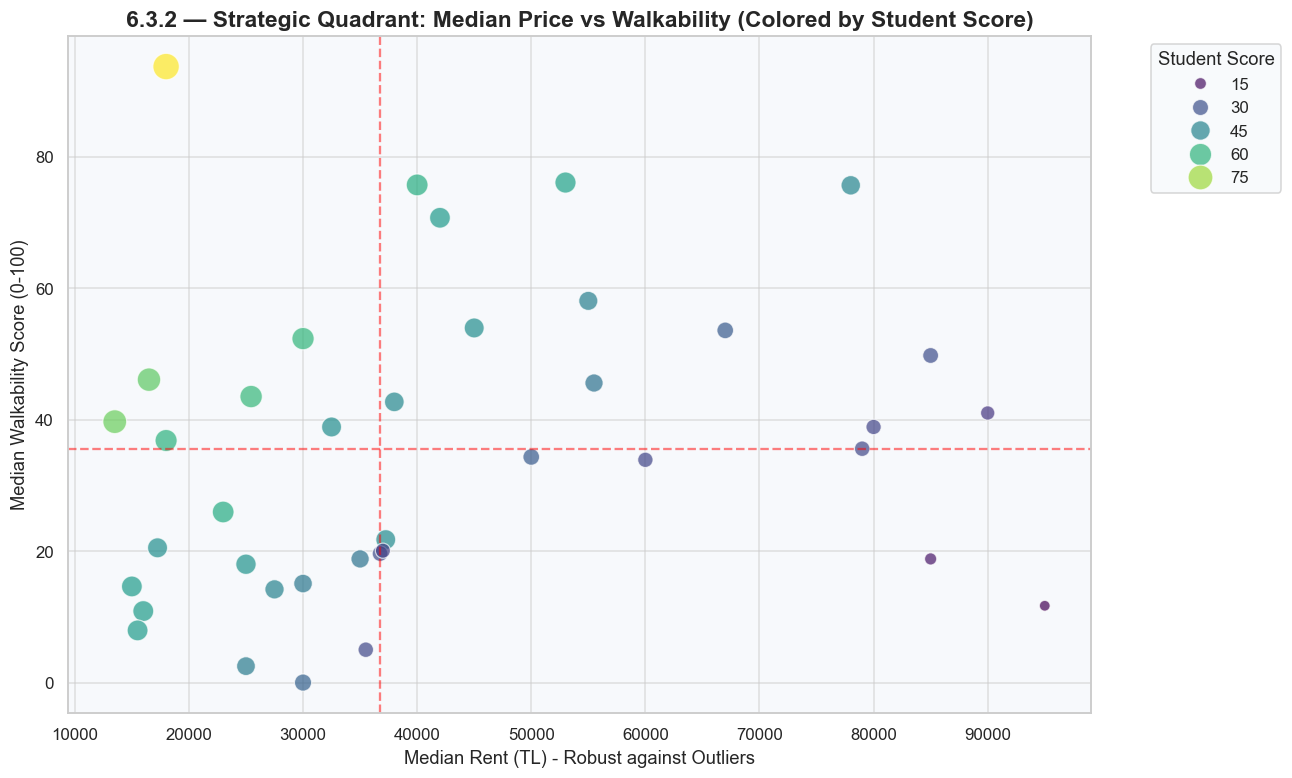

In [35]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Veriyi ilce bazinda grupla (Fiyat icin de MEDIAN kullaniyoruz)
district_stats = df.groupby('district').agg({
    'price': 'median',
    'walkability_score': 'median',
    'student_score': 'median'
}).reset_index()

plt.figure(figsize=(12, 8))

# Scatter Plot
scatter = sns.scatterplot(data=district_stats, x='price', y='walkability_score',
                          hue='student_score', size='student_score',
                          palette='viridis', sizes=(50, 300), alpha=0.7)

# Thresholds
plt.axhline(district_stats['walkability_score'].median(), color='red', linestyle='--', alpha=0.5)
plt.axvline(district_stats['price'].median(), color='red', linestyle='--', alpha=0.5)

# Baslik ve Etiketler
plt.title('6.3.2 — Strategic Quadrant: Median Price vs Walkability (Colored by Student Score)', fontsize=15, fontweight='bold')
plt.xlabel('Median Rent (TL) - Robust against Outliers')
plt.ylabel('Median Walkability Score (0-100)')

# Legend disari al ki grafik kapanmasin
plt.legend(title='Student Score', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('p1_plots/6_3_2_student_sweet_spot.png', dpi=300, bbox_inches='tight')
plt.show()

_This scatter plot serves as the core decision-making tool of the project. By intersecting Median Rent and Median Walkability, we divide the Istanbul rental market into four strategic zones._

* The Logic of Medians: We utilized median thresholds (price≈37k TL, walkability ≈35) to ensure the analysis remains robust against extreme outliers.

**Quadrant Definitions**

* Top-Left (Student Sweet Spot): Affordable + walkable. Fatih dominates this zone with a notably high student score (~86).
* Top-Right (Premium Central): Beşiktaş, Şişli, Kadıköy, Beyoğlu — high walkability but elevated rent.
* Bottom-Right (Inefficient): High-cost areas with poor urban integration; the least favorable for student optimization.

_Final Verdict: Fatih emerges as the clear winner — exceptional walkability (~94) combined with affordable per-room costs make it the singular standout for student housing optimization._

---
### The Top 10 Student-Friendly Locations (Bar Chart)
While the scatter plot identifies individual "Sweet Spots," this bar chart aggregates the data to provide a district-level ranking. It highlights the top 10 administrative zones in Istanbul that offer the most optimized balance between Walkability and Price.

**What this graph reveals:**

* Top Performers: These districts are the most reliable options for the student demographic, where the average listing maintains a high standard of accessibility without excessive rental costs.

* Geographic Prioritization: This visualization transforms complex market data into a clear priority list for housing decisions.

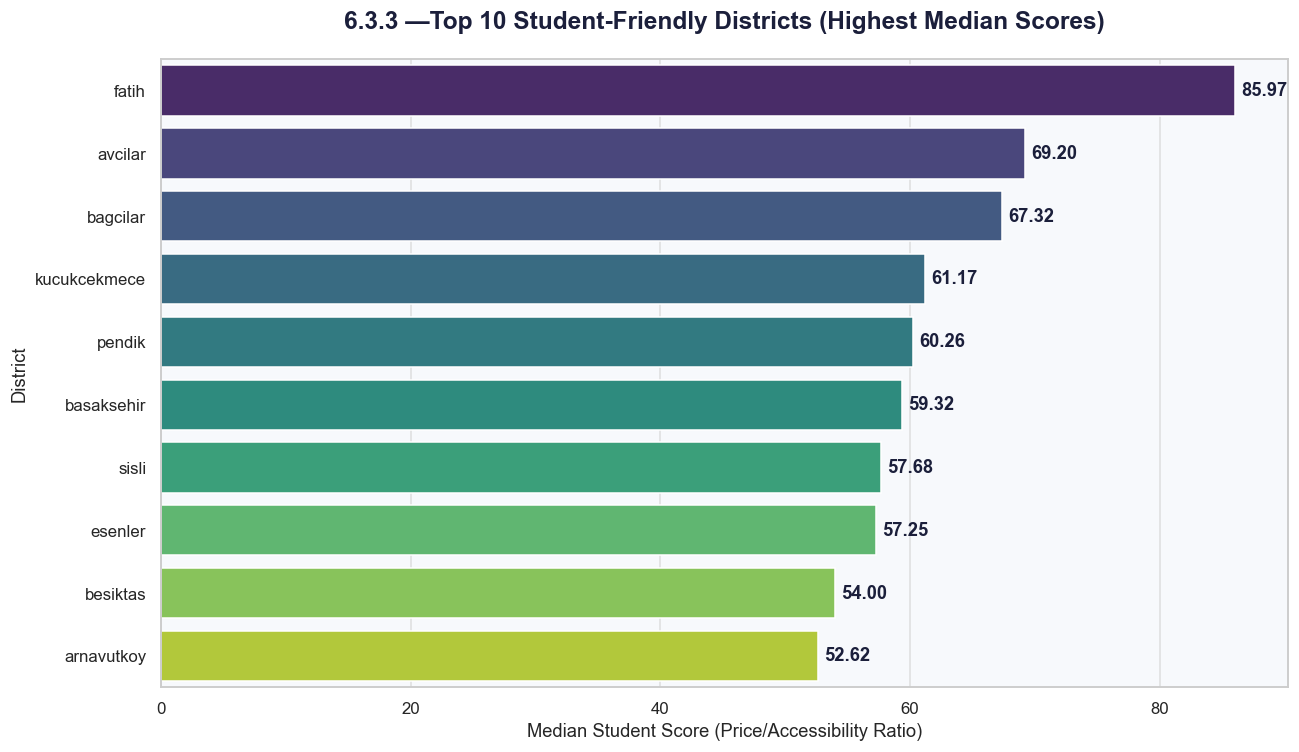

In [36]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
# Ilce bazinda ogrenci skorlarini MEDYAN kullanarak hesapla.
# Bu, ilcedeki uc orneklerin (cok ucuz/pahali evler) siralamayi bozmasini engeller.
student_districts = df.groupby('district')['student_score'].median().sort_values(ascending=False).head(10)

# Grafik alanini olustur
plt.figure(figsize=(12, 7))

# Bar Chart: Palette uyarisini gidermek icin hue atamasi yapiyoruz.
# x ve y yer degistirerek yatay bar chart elde ediyoruz.
sns.barplot(x=student_districts.values, y=student_districts.index,
            hue=student_districts.index, palette='viridis', legend=False)

# Grafik basligi ve etiketler
plt.title('6.3.3 —Top 10 Student-Friendly Districts (Highest Median Scores)',
          fontsize=16, fontweight='bold', color=C_DARK, pad=20)
plt.xlabel('Median Student Score (Price/Accessibility Ratio)', fontsize=12)
plt.ylabel('District', fontsize=12)

# Cubuklarin uzerine skor degerlerini yazdirmak
for i, value in enumerate(student_districts.values):
    plt.text(value + 0.5, i, f'{value:.2f}', va='center', fontweight='bold', color=C_DARK)

plt.tight_layout()
plt.savefig('p1_plots/6_3_3_top10_student_districts.png', dpi=300, bbox_inches='tight')
plt.show()

_The bar chart reveals a striking shift under the per-room affordability framework: while Fatih still leads decisively (85.97), peripheral districts like Avcılar (69.20) and Bağcılar (67.32) now outrank traditional central zones. The presence of Küçükçekmece, Pendik, Başakşehir, Esenler, and Arnavutköy in the top 10 highlights this trade-off._

---
### Top 10 Most Walkable Districts vs. Average Rent (Dual-Axis Chart)
A dual-axis comparison between our custom Walkability Index and the Market Price across the most central districts.

We want to find "Student-Friendly" areas (High Walkability, Low Price).

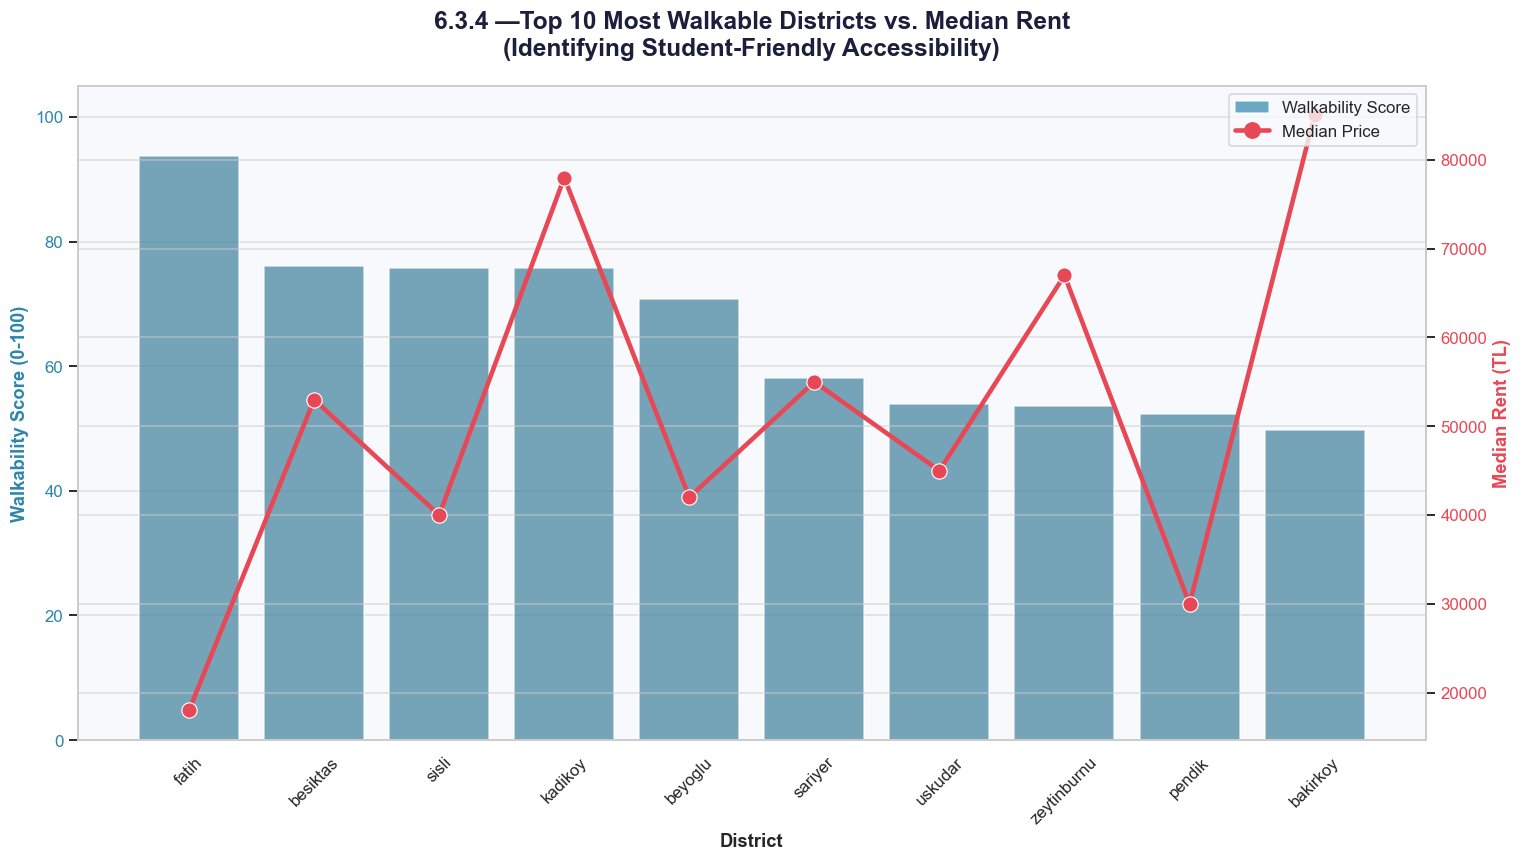

In [37]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Veriyi ilce bazinda grupla
district_comp = df.groupby('district').agg({
    'walkability_score': 'median',
    'price': 'median'
}).sort_values(by='walkability_score', ascending=False).head(10).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 8))

# Birincil Eksen: Walkability Score (Bar Chart)
sns.barplot(data=district_comp, x='district', y='walkability_score',
            ax=ax1, color=C_PRIMARY, alpha=0.7)

ax1.set_xlabel('District', fontsize=12, fontweight='bold')
ax1.set_ylabel('Walkability Score (0-100)', color=C_PRIMARY, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=C_PRIMARY)
ax1.tick_params(axis='x', rotation=45) # Uyariyi onleyen modern yontem
ax1.set_ylim(0, 105)

# Ikincil Eksen: Price (Line Chart)
ax2 = ax1.twinx()
sns.lineplot(data=district_comp, x='district', y='price',
             ax=ax2, color=C_SECONDARY, marker='o', markersize=10, linewidth=3, label='Median Price')
ax2.set_ylabel('Median Rent (TL)', color=C_SECONDARY, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=C_SECONDARY)

# Baslik ve Duzenleme
plt.title('6.3.4 —Top 10 Most Walkable Districts vs. Median Rent\n(Identifying Student-Friendly Accessibility)',
          fontsize=16, fontweight='bold', color=C_DARK, pad=20)

from matplotlib.lines import Line2D
patch = plt.Rectangle((0, 0), 1, 1, fc=C_PRIMARY, alpha=0.7, label='Walkability Score')
line = Line2D([0], [0], color=C_SECONDARY, marker='o', markersize=10, linewidth=3, label='Median Price')
ax2.legend(handles=[patch, line], loc='upper right')

plt.tight_layout()
plt.savefig('p1_plots/6_3_4_walkability_vs_price_dual.png', dpi=300, bbox_inches='tight')
plt.show()

_While Fatih leads in pure accessibility due to its high station density, Kadıköy commands the highest 'lifestyle premium' (~720 TL/m², the highest in Istanbul) despite a lower walkability score, indicating a prestige effect not captured by transit metrics alone._

---
### Room Count vs. Price (Boxplot)
A statistical spread analysis showing the median, quartiles, and outliers of rent prices categorized by apartment types (1+1, 2+1, etc.).

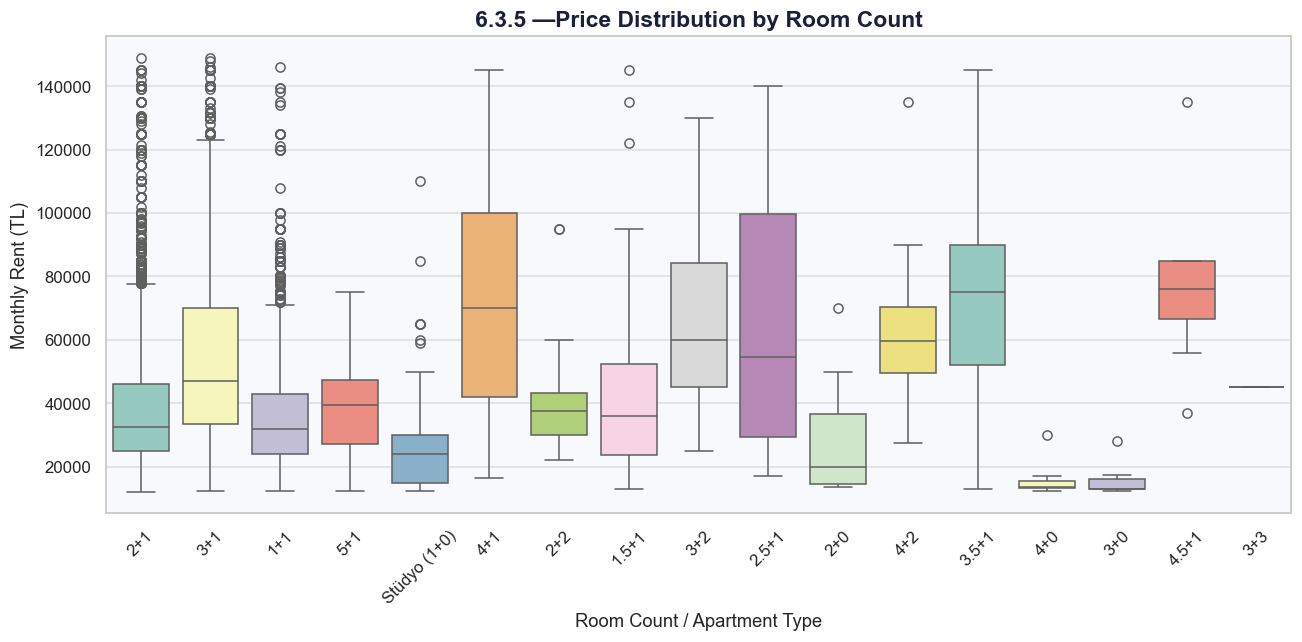

In [38]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='room_count', y='price',hue='room_count', palette='Set3', legend=False)

plt.title('6.3.5 —Price Distribution by Room Count', fontsize=15, fontweight='bold', color=C_DARK)
plt.ylabel('Monthly Rent (TL)')
plt.xlabel('Room Count / Apartment Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('p1_plots/6_3_5_roomcount_price.png', dpi=300, bbox_inches='tight')
plt.show()

_The high degree of overlap between 1+1 and 2+1 price ranges suggests that in Istanbul, locational walkability often outweighs physical room count in determining market value_

_The presence of numerous high-price outliers in small apartment types (1+1 and Stüdyo) further confirms that central location utility provides a significant price premium regardless of square footage._

---
### Room Configuration vs. Student Suitability (Box Plot)

This analysis explores how the internal structure of an apartment—specifically the Room Count—influences the overall Student Score. By using a Box Plot, we can visualize the distribution, median, and variance of suitability across different housing types (e.g., 1+1, 2+1, 3+1).

Objectives:

* Identifying the Optimal Layout: To determine which room configurations offer the best price-location balance for student demographics

* Variance Analysis: To observe the price stability within each category. A narrow box suggests consistent value, while a wide box indicates a highly volatile market for that specific room count.

* Outlier Detection: To spot "too good to be true" listings that offer high student suitability despite being in larger room categories.

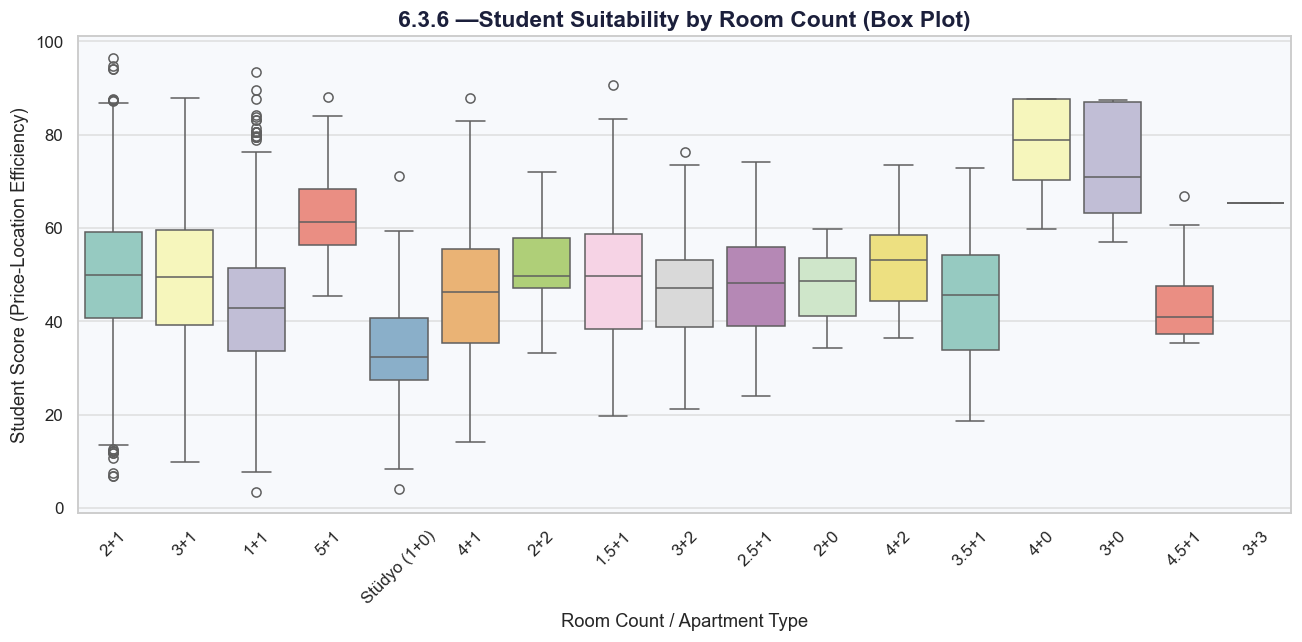

In [39]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Oda sayisina gore ogrenci skoru dagilimi
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='room_count', y='student_score', hue='room_count', palette='Set3', legend=False)

plt.title('6.3.6 —Student Suitability by Room Count (Box Plot)', fontsize=15, fontweight='bold', color=C_DARK)
plt.xlabel('Room Count / Apartment Type')
plt.ylabel('Student Score (Price-Location Efficiency)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('p1_plots/6_3_6_room_vs_student_score.png', dpi=300, bbox_inches='tight')
plt.show()

_The box plot reveals a clear pattern under the per-room affordability framework: large multi-bedroom configurations (4+0, 3+0) achieve the highest median student scores (70-78), as their cost burden distributes across more occupants. Conversely, Stüdyo (1+0) ranks lowest (~32) since the entire rent falls on a single tenant. This confirms that for student demographics, shared multi-room apartments offer significantly better cost efficiency than compact studios._

---
### Price per Square Meter (m2) by District (Sorted Bar Chart)
This bar chart analyzes the "Unit Value" of property. It reveals which districts are expensive not just because the houses are large, but because the land itself is high-value.

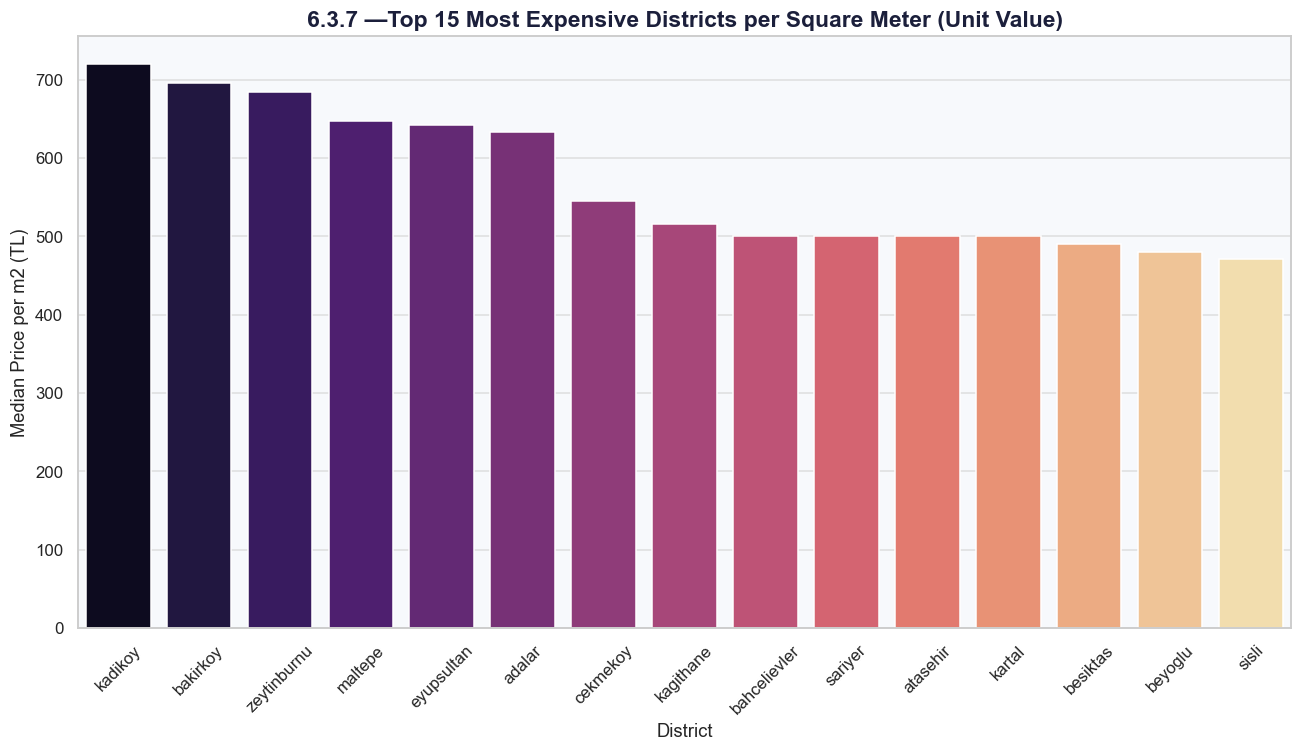

In [40]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Birim fiyat hesaplama
df['price_per_m2'] = df['price'] / df['area_m2']

# Ilce bazinda MEDYAN birim fiyatlari hesapla ve ilk 15'i sec
m2_dist_stats = df.groupby('district')['price_per_m2'].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 7))

sns.barplot(x=m2_dist_stats.index, y=m2_dist_stats.values,
            hue=m2_dist_stats.index, palette='magma', legend=False)

plt.title('6.3.7 —Top 15 Most Expensive Districts per Square Meter (Unit Value)',
          fontsize=15, fontweight='bold', color=C_DARK)
plt.ylabel('Median Price per m2 (TL)')
plt.xlabel('District')

plt.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('p1_plots/6_3_7_m2_district.png', dpi=300, bbox_inches='tight')
plt.show()

_Kadıköy maintains the highest price-per-m² in Istanbul (~720 TL/m²), indicating that renters in this area are paying significantly more for location prestige than for actual living space._

---
### Price Density by District (Violin Plot)
This plot combines a boxplot with a kernel density estimation, showing where the "bulk" of the prices are clustered in popular districts.

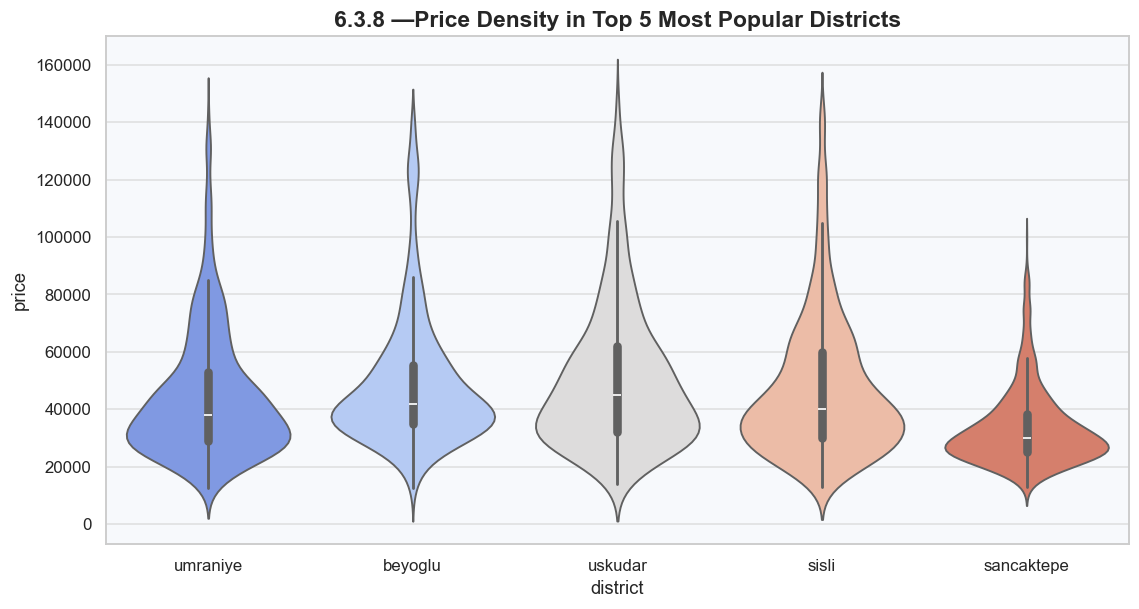

In [41]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# En çok ilanı olan 5 ilçeyi bul ve sadece onları filtrele
top_5_districts = df['district'].value_counts().head(5).index
df_top5 = df[df['district'].isin(top_5_districts)]

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_top5,
    x='district',
    y='price',
    hue='district',
    palette='coolwarm',
    legend=False
)

plt.title('6.3.8 —Price Density in Top 5 Most Popular Districts', fontsize=15)
plt.savefig('p1_plots/6_3_8_price_density.png', dpi=300, bbox_inches='tight')
plt.show()

_Among the top 5 listed districts, Üsküdar and Şişli show the widest price distributions with long upper tails, while Sancaktepe demonstrates the tightest cluster at the lower end (~30k TL median). Ümraniye and Beyoğlu hold similar median levels (~37-42k TL) despite vastly different geographic profiles, suggesting that listing density does not directly correlate with price spread._

### 6.4 .Key Observations & Surprising Insights

After conducting the bivariate and multivariate analysis, the following relationships stand out as critical for our price prediction model:

1. The Strongest Predictor: Price vs. Area (m2)

* Relationship: Moderate-to-Strong Positive (≈ 0.50).

* Observation: As expected, square footage is the most dominant numerical factor. The regression line shows a steady upward trend, confirming that regardless of the district, size remains a primary driver of cost.

2. The "Walkability-Price" Paradox

* Relationship: Non-Monotonic.

* Observation: Prices climb steadily with walkability, peaking in the 70-80 range (~52k TL), then drop sharply at the 80-100 (Central Hubs) bin (~30k TL). The 60-70 bin is empty as no district falls within that range under the expanded walkability methodology.

* Insight: Despite the overall positive relationship, Istanbul's most walkable areas (80-100) are dominated by historical centers like Fatih, where older building stock and smaller units pull average rents below the broader market. This creates the paradox that the most accessible district is also among the cheapest.

3. Location over Size: Room Count Overlap

* Relationship: High Overlap.

* Observation: There is a significant overlap in the price ranges of 1+1 and 2+1 apartments.

* Insight: This proves that in Istanbul, location (Walkability) often outweighs physical room count. A compact 1+1 in a walkable district like Beşiktaş is frequently more expensive than a spacious 2+1 in a peripheral district like Esenyurt.

4. The "Lifestyle Premium" in Kadıköy

* Relationship: Highest Price-per-m².

* Observation: Kadıköy maintains the highest median price-per-m² (~720 TL/m²) in Istanbul, followed by Bakırköy (~695) and Zeytinburnu (~685). Notably, Beşiktaş ranks only 13th in unit price (~490 TL/m²).

* Insight: This indicates that Kadıköy carries a strong "prestige factor" or "lifestyle premium" reflected in land value itself. Beşiktaş's premium pricing, by contrast, appears to come from larger unit sizes rather than land scarcity.

5. Student Score Trade-off

* Relationship: Strong Negative Correlation with Price (≈ -0.54).

* Observation: Under the new per-room affordability methodology, the trade-off between cost and student suitability is more pronounced. As price increases, the student suitability score declines sharply.

* Insight: The shift from absolute price to per-room cost reveals a counter-intuitive finding: peripheral districts with large affordable apartments (Avcılar, Bağcılar, Küçükçekmece) compete with central walkable hubs (Fatih, Şişli) for student-friendliness, since shared living amortizes location premiums.

---
Based on our Visual Exploratory Data Analysis (EDA), here are the final results:

* **Data Quality Success:** Approximately **11,700 listings** were processed. After removing missing values and applying domain-based outlier filtering, the dataset is now clean, consistent, and ready for machine learning applications.

* **Walkability vs. Price:** A moderate positive relationship (≈ 0.32) is observed between walkability and rent.

* **Affordability Trade-off (Student Score):** The Student Score, computed from per-room cost percentile, shows a **moderate-strong negative correlation with price (≈ -0.54)**.

* **Non-Linear Market Behavior:** The relationship between walkability and price is non-monotonic, peaking in the 70-80 range (~52k TL), with a sharp drop at 80-100 (~30k) and declining at extreme values.

* **Strategic Market Segmentation:** The Strategic Quadrant analysis identifies **Fatih** as the singular standout combining high walkability and per-room affordability. Top-right districts (Beşiktaş, Şişli, Kadıköy, Beyoğlu) carry the "premium central" trade-off.

* **District-Level Insight:** Under the per-room methodology, **Fatih leads decisively (85.97)**, followed by peripheral districts like **Avcılar (69.20), Bağcılar (67.32)** that benefit from larger affordable apartments. **Şişli, Beşiktaş, Beyoğlu, Küçükçekmece, Pendik** still rank in the top 10 but trade pure walkability for higher per-room costs. **Kadıköy** maintains the highest price-per-m² premium.

_Final Status: The final dataset (istanbul_emlak_final.csv) is fully prepared for the next phase: regression modeling and price prediction._

# 7. Key Findings & Next Steps

### **7.1. Top 5 Key Findings from EDA**

* **The Dominance of Physical Scale:** `area_m2` emerged as the strongest single predictor of price (correlation ≈ 0.50).

* **The Accessibility-Affordability Trade-off:** A strong negative correlation (≈ **-0.54**) between `student_score` (per-room cost based) and `price` confirms that high accessibility rarely pairs with low costs.

* **Non-Linear Market Behavior:** The relationship between walkability and price is non-monotonic, peaking in the 70-80 range (~52k TL), with a sharp drop at 80-100 (~30k TL).

* **Strategic "Sweet Spots":** Under the per-room framework, **Fatih leads decisively (85.97)**. Surprisingly, peripheral districts like **Avcılar (69.20), Bağcılar (67.32), Küçükçekmece (61.17)** now outrank central hubs because large affordable apartments minimize per-person cost.

* **District Prestige Premium:** **Kadıköy** holds the highest price-per-m² (~720 TL/m²) — Beşiktaş ranks only 13th. The "lifestyle premium" is tied to land value, not unit size.

---

### **7.2. Most Predictive Features**

Based on the correlation analysis and visual trends, the following features are expected to have the highest predictive power in our regression model:

1. **`area_m2` (Numerical):** Correlation ≈ 0.50 with target — the strongest single predictor.
2. **`walkability_score` (Engineered):** Correlation ≈ 0.32 — captures location utility.
3. **`district` (Categorical):** Proxy for prestige and demand (e.g., Kadıköy's m² premium).
4. **`total_rooms` (Numerical):** Correlation ≈ 0.33 — secondary structural context.

---

### **7.3. Remaining Data Quality Issues**

While the dataset is now structurally sound and "ML-Ready," a few inherent limitations remain:

* **Geographic Bias:** Because the data originated from a single platform (Sahibinden.com), certain districts with higher digital turnover (like Şişli, Ümraniye, and Sancaktepe) are over-represented compared to others.
* **Walkability Score Coverage:** The `raw_stats` dictionary covers all 39 of Istanbul's official districts. Values are approximated from public IBB transit data, YÖK university registries, and qualitative social/amenity indices. While this provides full geographic coverage, the scores remain estimates rather than measured field data, and may benefit from refinement in future iterations.
* **Student Score Methodology:** The current student score uses per-room cost (price ÷ total_rooms) under percentile rank. This rewards larger shared apartments, which may favor peripheral districts over central walkable ones if a single tenant's perspective is what matters.
* **Temporal Constraints:** The data represents a "snapshot" of the market as of early 2026; it does not account for seasonal spikes (e.g., September university opening periods).
* **Missing Contextual Variables:** Factors such as **building age, floor level, and renovation status** were not reliably available in the raw scrape. These "hidden" features likely contribute to some of the price variance observed in our box plots.

---

> **Next Step:** Proceed to **Phase 2: Regression Modeling**, where we will apply Log-Transformation to the `price` variable to address the right-skewness (1.473) identified in Section 5.3.